In [19]:
import subprocess, sys

packages = ['pyreadstat', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'balance', 'statsmodels']
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg} installed.')

In [20]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pyreadstat
from datetime import datetime

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

os.makedirs('figs', exist_ok=True)

if 'src' not in sys.path:
    sys.path.insert(0, '.')

from src import config, data_loading, analysis, plotting
for mod in [config, data_loading, analysis, plotting]:
    importlib.reload(mod)

from src.config import *
from src.data_loading import load_nfhs5, load_nfhs4

COLOR_MALE     = "#020a5e"
COLOR_FEMALE   = "#d62727"
COLOR_PRE      = "blue"
COLOR_POST     = "red"

In [21]:
df_persons, male_2021, female_2021 = load_nfhs5('data_real/household_2021_recode/IAPR7EFL.DTA')
df_n4, male_2016, female_2016 = load_nfhs4('data_real/household_2016/IAPR74FL.DTA')

NFHS-5: 33/33 columns found
Loaded 2,843,917 person rows
Cleaned 20 zero values in 'First SYSTOLIC reading'
Cleaned 57 zero values in 'First DIASTOLIC reading'
Cleaned 7 zero values in 'Second SYSTOLIC reading'
Cleaned 40 zero values in 'Second DIASTOLIC reading'
Cleaned 12 zero values in 'Third SYSTOLIC reading'
Cleaned 37 zero values in 'Third DIASTOLIC reading'
Cleaned 1,481 implausible 'Height' (>250.0)
Cleaned 5 implausible 'Waist curcumference' (>200.0)

Total persons with BP: 1,852,899
Male: 865,780  |  Female: 987,119
Height — Male: 97,890  Female: 707,845
BMI (804,827)
Waist (805,023)
NFHS-4: 33/33 columns found
Loaded NFHS-4: 2,869,043 person-rows
NFHS-4: Cleaned 6 zero values in 'First SYSTOLIC reading'
NFHS-4: Cleaned 12 zero values in 'First DIASTOLIC reading'
NFHS-4: Cleaned 1 zero values in 'Second DIASTOLIC reading'
NFHS-4: Cleaned 1 zero values in 'Third SYSTOLIC reading'

NFHS-4 persons with BP: 811,608
Male: 111,608  |  Female: 700,000
BMI — Male: 111,316  Female: 69

---
# COVID Pre/Post Split — Household Data

NFHS-5 split: pre-COVID (Jun 2019 – Feb 2020) vs post-COVID (Nov 2020 – Apr 2021). 

In [22]:
for df_sex in [male_2021, female_2021]:
    df_sex.dropna(subset=['Year of interview', 'Month of interview'], inplace=True)
    df_sex['Interview Date'] = pd.to_datetime(
        df_sex['Year of interview'].astype(int).astype(str) + '-' +
        df_sex['Month of interview'].astype(int).astype(str) + '-01'
    )

year_m = male_2021['Year of interview']; month_m = male_2021['Month of interview']
year_f = female_2021['Year of interview']; month_f = female_2021['Month of interview']

pre_m  = (year_m == 2019) | ((year_m == 2020) & (month_m <= 2))
post_m = ((year_m == 2020) & (month_m >= 11)) | (year_m == 2021)
pre_f  = (year_f == 2019) | ((year_f == 2020) & (month_f <= 2))
post_f = ((year_f == 2020) & (month_f >= 11)) | (year_f == 2021)

nfhs5_pre_covid_male    = male_2021[pre_m]
nfhs5_post_covid_male   = male_2021[post_m]
nfhs5_pre_covid_female  = female_2021[pre_f]
nfhs5_post_covid_female = female_2021[post_f]

print(f"Pre-COVID  Male: {len(nfhs5_pre_covid_male):,}   Female: {len(nfhs5_pre_covid_female):,}")
print(f"Post-COVID Male: {len(nfhs5_post_covid_male):,}   Female: {len(nfhs5_post_covid_female):,}")
gap_m = len(male_2021) - len(nfhs5_pre_covid_male) - len(nfhs5_post_covid_male)
gap_f = len(female_2021) - len(nfhs5_pre_covid_female) - len(nfhs5_post_covid_female)
print(f"Gap (Mar-Oct 2020, excluded) Male: {gap_m:,}   Female: {gap_f:,}")

Pre-COVID  Male: 553,802   Female: 626,376
Post-COVID Male: 261,458   Female: 304,545
Gap (Mar-Oct 2020, excluded) Male: 50,520   Female: 56,198


In [23]:
SBP_COL = 'First SYSTOLIC reading'
DBP_COL = 'First DIASTOLIC reading'

bmi_ranges = {
    "14-": (1, 15), "15": (15, 16), "16": (16, 17), "17": (17, 18),
    "18": (18, 19), "19": (19, 20), "20": (20, 21), "21": (21, 22),
    "22": (22, 23), "23": (23, 24), "24": (24, 25), "25": (25, 26),
    "26": (26, 27), "27+": (27, 99),
}


def weighted_mean(vals, wts):
    mask = np.isfinite(vals) & np.isfinite(wts) & (wts > 0)
    if not mask.any():
        return np.nan
    return np.average(vals[mask], weights=wts[mask])


def get_mean_bp_by_age_bmi(data_base, data_compare, ages=range(15, 50), bmi_dict=None):
    results = {}
    for age in ages:
        for bmi_label, (lo, hi) in bmi_dict.items():
            base = data_base[(data_base['Age of household members'] == age) &
                             (data_base['BMI'] >= lo) & (data_base['BMI'] < hi)]
            comp = data_compare[(data_compare['Age of household members'] == age) &
                                (data_compare['BMI'] >= lo) & (data_compare['BMI'] < hi)]
            if len(base) >= 10 and len(comp) >= 10:
                sb = weighted_mean(base[SBP_COL].values, base['weight'].values)
                sc = weighted_mean(comp[SBP_COL].values, comp['weight'].values)
                db = weighted_mean(base[DBP_COL].values, base['weight'].values)
                dc = weighted_mean(comp[DBP_COL].values, comp['weight'].values)
                if np.isfinite(sb) and np.isfinite(sc):
                    results[(age, bmi_label)] = {
                        'systolic_diff': sc - sb,
                        'diastolic_diff': dc - db,
                    }
    return results


def prepare_heatmap_data(results):
    rows = []
    for (age, bmi), vals in results.items():
        rows.append({'Age': age, 'BMI': bmi,
                     'Systolic Difference': vals['systolic_diff'],
                     'Diastolic Difference': vals['diastolic_diff']})
    return pd.DataFrame(rows)


def plot_heatmap(df, title_suffix, vmin=-8, vmax=8):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, col, label in [(axes[0], 'Systolic Difference', 'Systolic'),
                            (axes[1], 'Diastolic Difference', 'Diastolic')]:
        pivot = df.pivot(index='BMI', columns='Age', values=col)
        sns.heatmap(pivot, annot=False, cmap='coolwarm', center=0,
                    linewidths=.5, vmin=vmin, vmax=vmax, ax=ax)
        ax.set_title(f'{label} BP Difference {title_suffix}')
    plt.tight_layout()
    fig.savefig(f'figs/{title_suffix.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

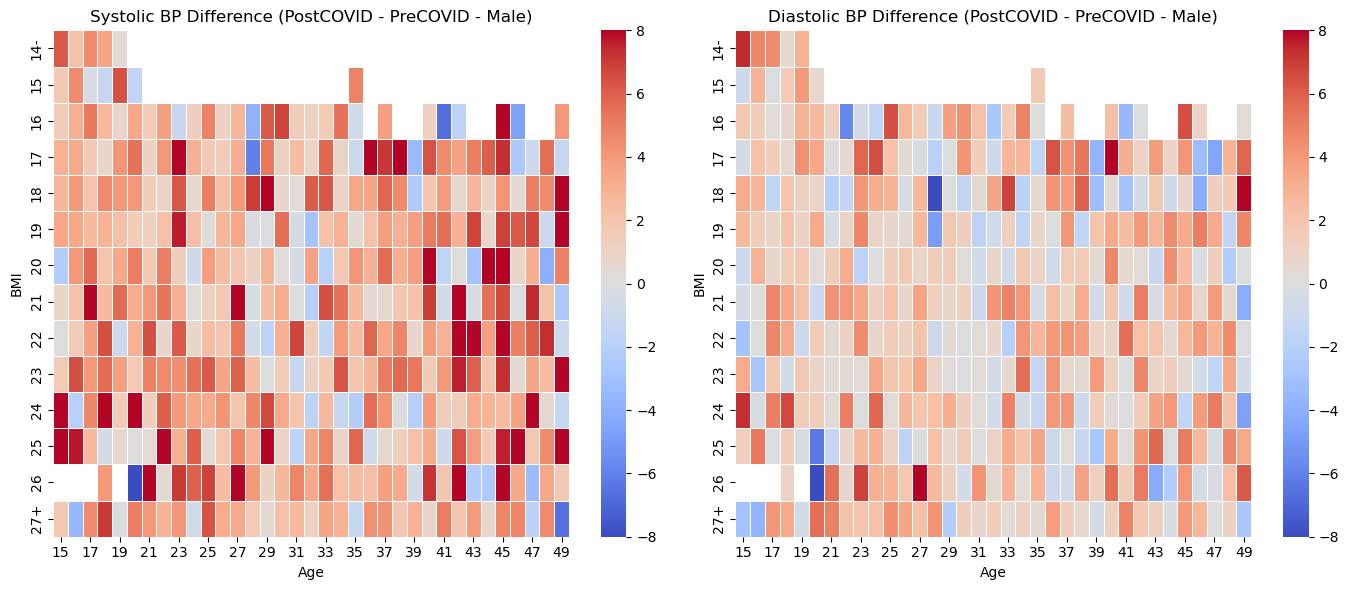

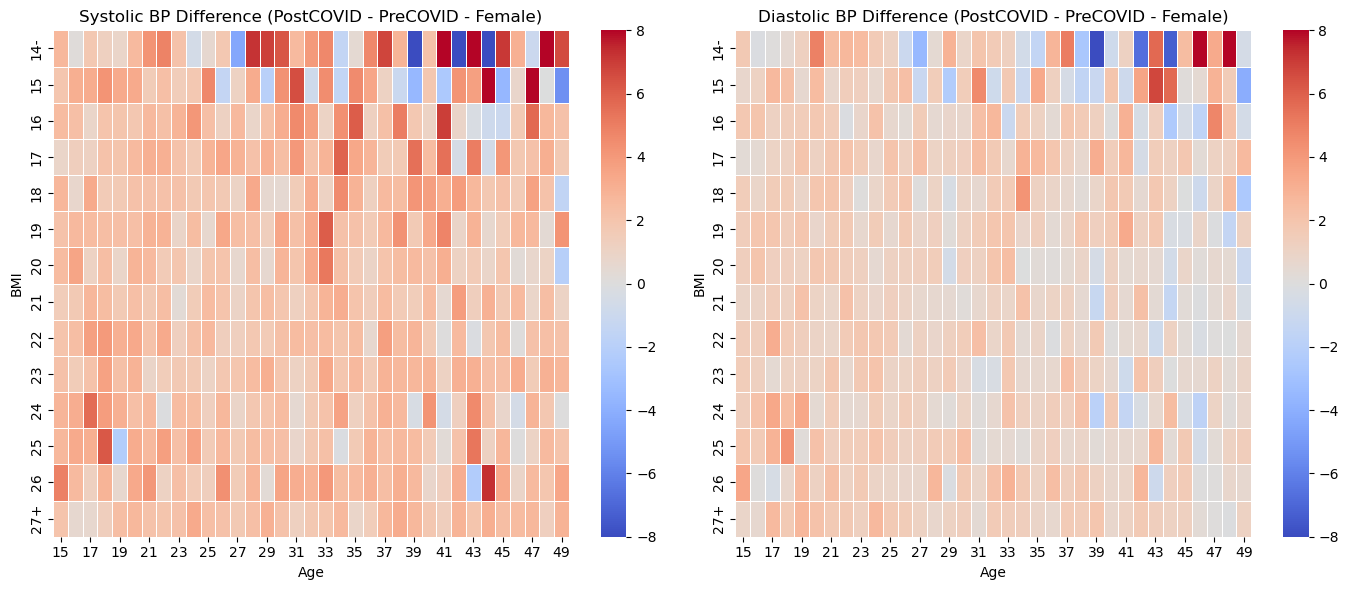

In [24]:
male_post_vs_pre = get_mean_bp_by_age_bmi(nfhs5_pre_covid_male, nfhs5_post_covid_male, bmi_dict=bmi_ranges)
female_post_vs_pre = get_mean_bp_by_age_bmi(nfhs5_pre_covid_female, nfhs5_post_covid_female, bmi_dict=bmi_ranges)

plot_heatmap(prepare_heatmap_data(male_post_vs_pre), '(PostCOVID - PreCOVID - Male)')
plot_heatmap(prepare_heatmap_data(female_post_vs_pre), '(PostCOVID - PreCOVID - Female)')

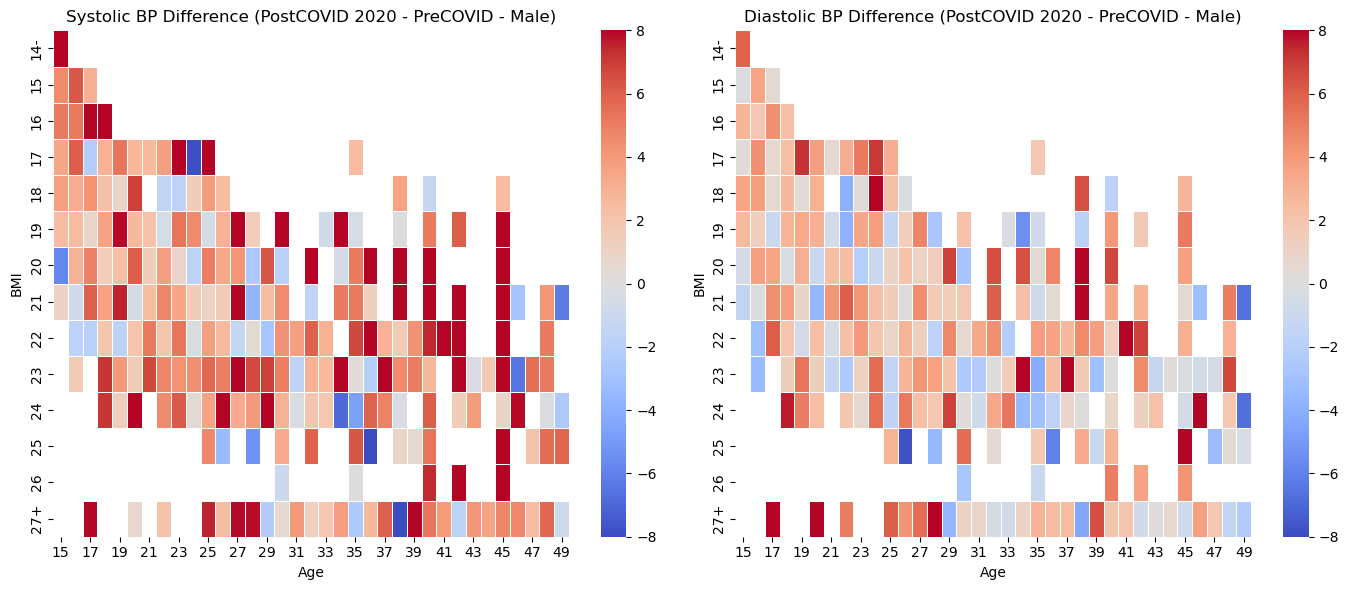

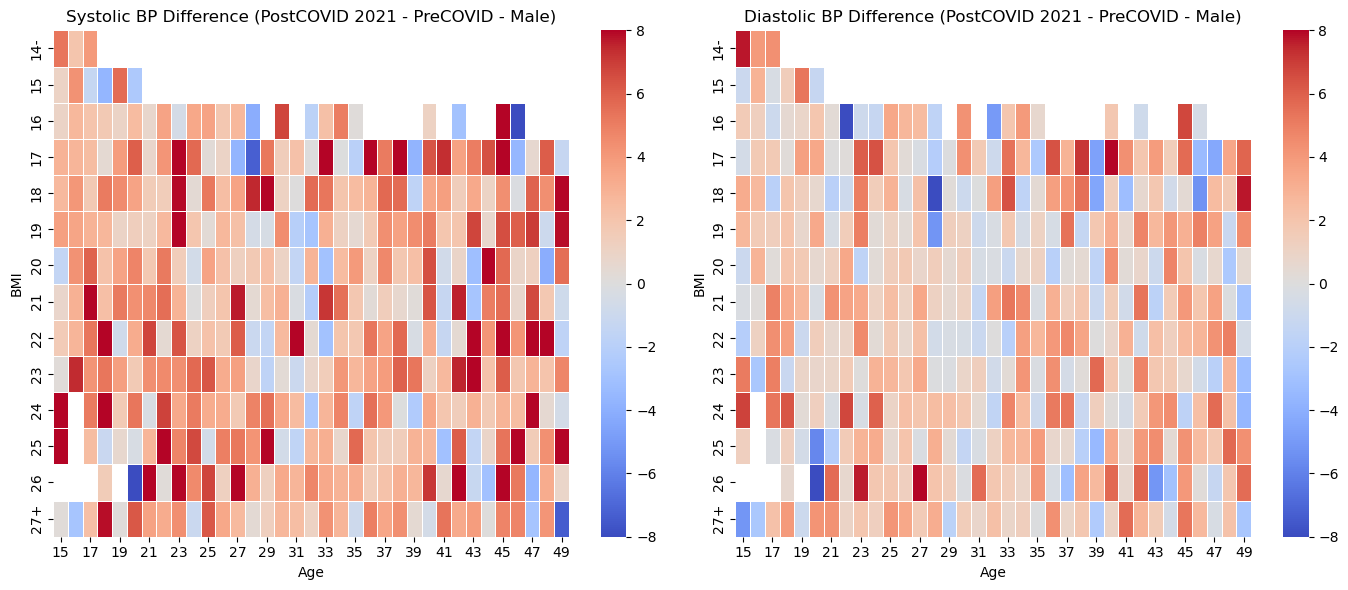

In [ ]:
male_2020   = nfhs5_post_covid_male[nfhs5_post_covid_male['Year of interview'] == 2020]
male_2021o  = nfhs5_post_covid_male[nfhs5_post_covid_male['Year of interview'] == 2021]
female_2020 = nfhs5_post_covid_female[nfhs5_post_covid_female['Year of interview'] == 2020]
female_2021o = nfhs5_post_covid_female[nfhs5_post_covid_female['Year of interview'] == 2021]
male_2019   = male_2021[male_2021['Year of interview'] == 2019]
female_2019 = female_2021[female_2021['Year of interview'] == 2019]

for label, base, comp in [
    ('(PostCOVID 2020 - PreCOVID - Male)', nfhs5_pre_covid_male, male_2020),
    ('(PostCOVID 2021 - PreCOVID - Male)', nfhs5_pre_covid_male, male_2021o),
    ('(PostCOVID 2020 - PreCOVID - Female)', nfhs5_pre_covid_female, female_2020),
    ('(PostCOVID 2021 - PreCOVID - Female)', nfhs5_pre_covid_female, female_2021o),
]:
    res = get_mean_bp_by_age_bmi(base, comp, bmi_dict=bmi_ranges)
    plot_heatmap(prepare_heatmap_data(res), label)

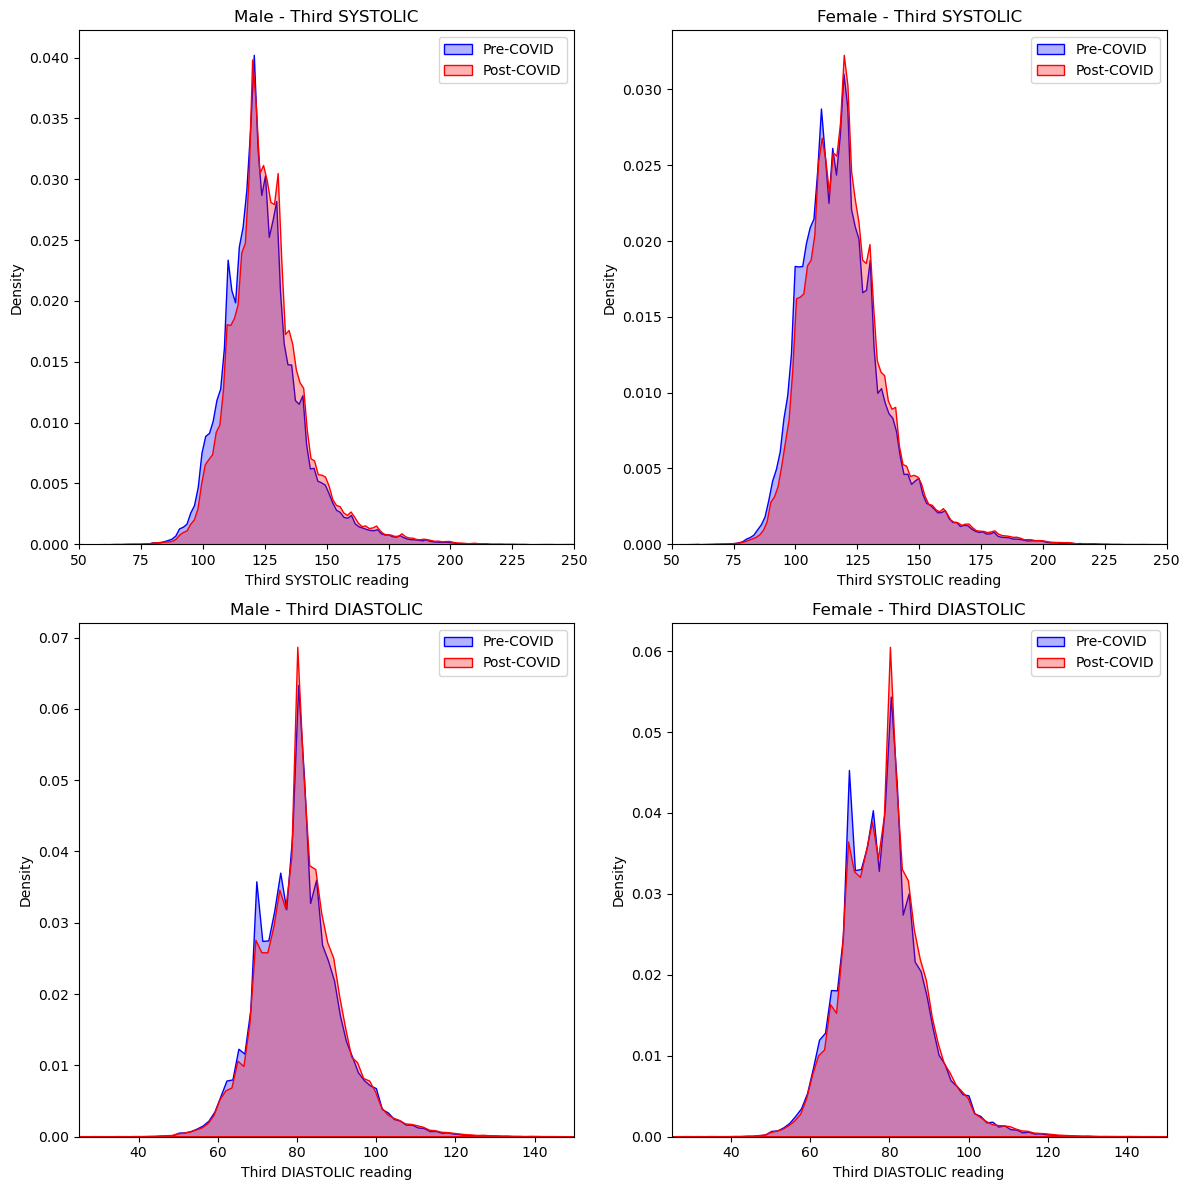

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
range_sys = [50, 250]
range_dia = [25, 150]

for ax, pre_df, post_df, col, title in [
    (axes[0, 0], nfhs5_pre_covid_male, nfhs5_post_covid_male, SBP_COL, 'Male - Systolic'),
    (axes[0, 1], nfhs5_pre_covid_female, nfhs5_post_covid_female, SBP_COL, 'Female - Systolic'),
    (axes[1, 0], nfhs5_pre_covid_male, nfhs5_post_covid_male, DBP_COL, 'Male - Diastolic'),
    (axes[1, 1], nfhs5_pre_covid_female, nfhs5_post_covid_female, DBP_COL, 'Female - Diastolic'),
]:
    pre_vals = pre_df[col].dropna()
    post_vals = post_df[col].dropna()
    pre_w = pre_df.loc[pre_vals.index, 'weight']
    post_w = post_df.loc[post_vals.index, 'weight']
    sns.kdeplot(pre_vals, weights=pre_w, color=COLOR_PRE, label='Pre-COVID',
                fill=True, alpha=0.3, bw_adjust=0.5, ax=ax)
    sns.kdeplot(post_vals, weights=post_w, color=COLOR_POST, label='Post-COVID',
                fill=True, alpha=0.3, bw_adjust=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlim(range_sys if 'Systolic' in title else range_dia)
    ax.legend()

plt.tight_layout()
fig.savefig('figs/covid_kde_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def weighted_describe(df, col, wcol='weight'):
    v = df[col].dropna()
    w = df.loc[v.index, wcol].fillna(1.0)
    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
    v, w = v[mask].values, w[mask].values
    wm = np.average(v, weights=w)
    var = np.average((v - wm)**2, weights=w)
    return pd.Series({'count': len(v), 'weighted_mean': wm, 'weighted_std': np.sqrt(var),
                      'min': v.min(), '25%': np.percentile(v, 25), '50%': np.percentile(v, 50),
                      '75%': np.percentile(v, 75), 'max': v.max()})

bp_cols = [SBP_COL, DBP_COL]

for label, pre, post in [
    ('Male', nfhs5_pre_covid_male, nfhs5_post_covid_male),
    ('Female', nfhs5_pre_covid_female, nfhs5_post_covid_female),
]:
    rows = {}
    for c in bp_cols:
        rows[f'Pre-COVID {c}'] = weighted_describe(pre, c)
        rows[f'Post-COVID {c}'] = weighted_describe(post, c)
    print(f"\n{label} BP (weighted, Pre vs Post COVID):")
    display(pd.DataFrame(rows).T)


Male Systolic (Pre vs Post COVID):


Pre-COVID Male                                                       Post-COVID Male                          \
      First SYSTOLIC reading Second SYSTOLIC reading Third SYSTOLIC reading First SYSTOLIC reading Second SYSTOLIC reading   
count            553805.0000             524564.0000            491167.0000            261459.0000             258562.0000   
mean                127.8264                125.5908               124.0855               130.6908                127.9132   
std                  17.1076                 16.2179                16.0789                17.4658                 16.4301   
min                   0.0000                  0.0000                 0.0000                 0.0000                  1.0000   
25%                 117.0000                116.0000               114.0000               120.0000                118.0000   
50%                 126.0000                124.0000               122.0000               129.0000                126.0000   
75%                 136.0000                133.0000               131.0000               139.0000                136.0000   
max                 299.0000                298.0000               297.0000               299.0000                291.0000   

                              
      Third SYSTOLIC reading  
count            254308.0000  
mean                126.0107  
std                  16.1630  
min                  10.0000  
25%                 116.0000  
50%                 124.0000  
75%                 133.0000  
max                 299.0000


Male Diastolic (Pre vs Post COVID):


Pre-COVID Male                                                          Post-COVID Male                           \
      First DIASTOLIC reading Second DIASTOLIC reading Third DIASTOLIC reading First DIASTOLIC reading Second DIASTOLIC reading   
count             553805.0000              524564.0000             491167.0000             261459.0000              258562.0000   
mean                  82.9063                  81.3980                 80.4030                 84.3180                  82.3867   
std                   11.6747                  10.9021                 11.1844                 11.6057                  10.7723   
min                    0.0000                   0.0000                  0.0000                  0.0000                   0.0000   
25%                   76.0000                  75.0000                 74.0000                 77.0000                  76.0000   
50%                   82.0000                  81.0000                 80.0000                 84.0000                  82.0000   
75%                   89.0000                  87.0000                 86.0000                 90.0000                  88.0000   
max                  297.0000                 296.0000                298.0000                299.0000                 298.0000   

                               
      Third DIASTOLIC reading  
count             254308.0000  
mean                  81.1687  
std                   11.5447  
min                    0.0000  
25%                   75.0000  
50%                   80.0000  
75%                   87.0000  
max                  298.0000


Female Systolic (Pre vs Post COVID):


Pre-COVID Female                                                     Post-COVID Female                          \
      First SYSTOLIC reading Second SYSTOLIC reading Third SYSTOLIC reading First SYSTOLIC reading Second SYSTOLIC reading   
count            626376.0000             600248.0000            568242.0000            304547.0000             302318.0000   
mean                123.5702                121.1341               119.5191               125.8865                123.1097   
std                  19.3910                 18.4047                18.0734                19.5649                 18.5344   
min                   0.0000                  0.0000                 0.0000                 0.0000                  0.0000   
25%                 110.0000                109.0000               108.0000               113.0000                111.0000   
50%                 121.0000                119.0000               118.0000               123.0000                120.0000   
75%                 132.0000                130.0000               128.0000               135.0000                132.0000   
max                 298.0000                280.0000               298.0000               292.0000                298.0000   

                              
      Third SYSTOLIC reading  
count            298906.0000  
mean                121.1407  
std                  18.0823  
min                   0.0000  
25%                 109.0000  
50%                 119.0000  
75%                 130.0000  
max                 291.0000


Female Diastolic (Pre vs Post COVID):


Pre-COVID Female                                                        Post-COVID Female                           \
      First DIASTOLIC reading Second DIASTOLIC reading Third DIASTOLIC reading First DIASTOLIC reading Second DIASTOLIC reading   
count             626375.0000              600248.0000             568242.0000             304547.0000              302318.0000   
mean                  80.9383                  79.3556                 78.3125                 82.1328                  80.2486   
std                   11.5978                  10.8844                 11.0822                 11.5262                  10.7162   
min                    0.0000                   0.0000                  0.0000                  0.0000                   0.0000   
25%                   74.0000                  72.0000                 71.0000                 75.0000                  73.0000   
50%                   80.0000                  79.0000                 78.0000                 81.0000                  80.0000   
75%                   87.0000                  85.0000                 84.0000                 88.0000                  86.0000   
max                  292.0000                 299.0000                298.0000                290.0000                 291.0000   

                               
      Third DIASTOLIC reading  
count             298906.0000  
mean                  79.0361  
std                   11.3424  
min                    0.0000  
25%                   72.0000  
50%                   79.0000  
75%                   85.0000  
max                  298.0000

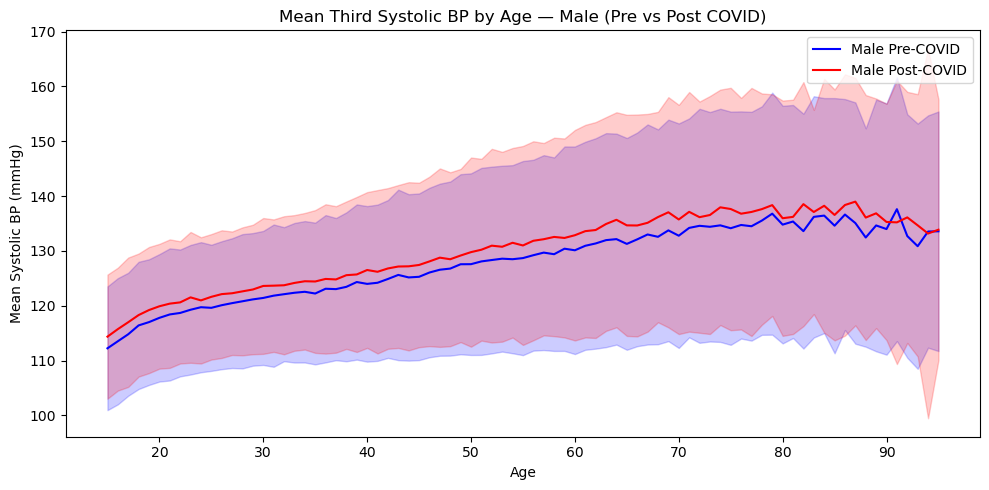

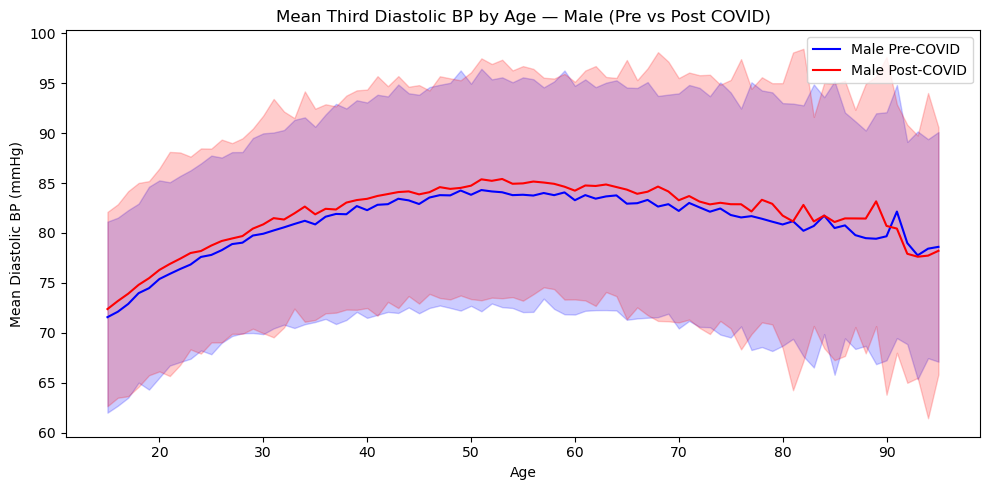

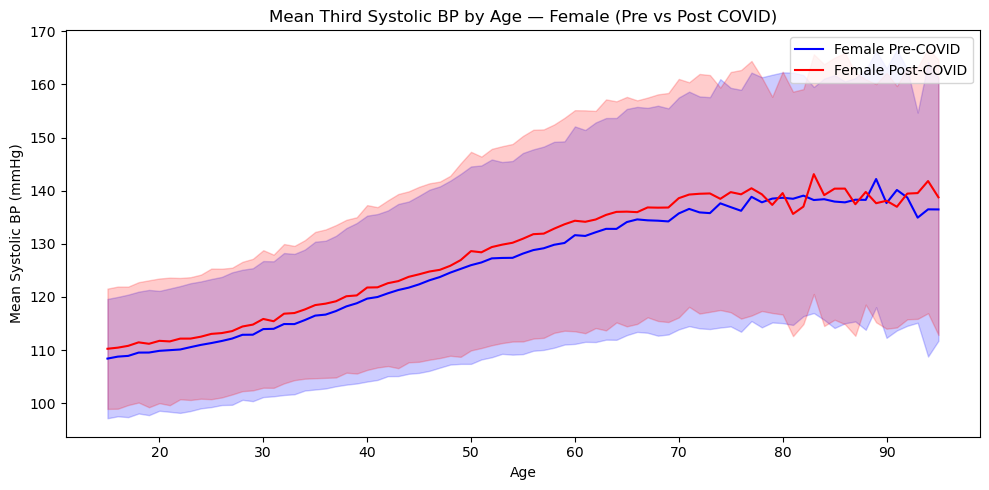

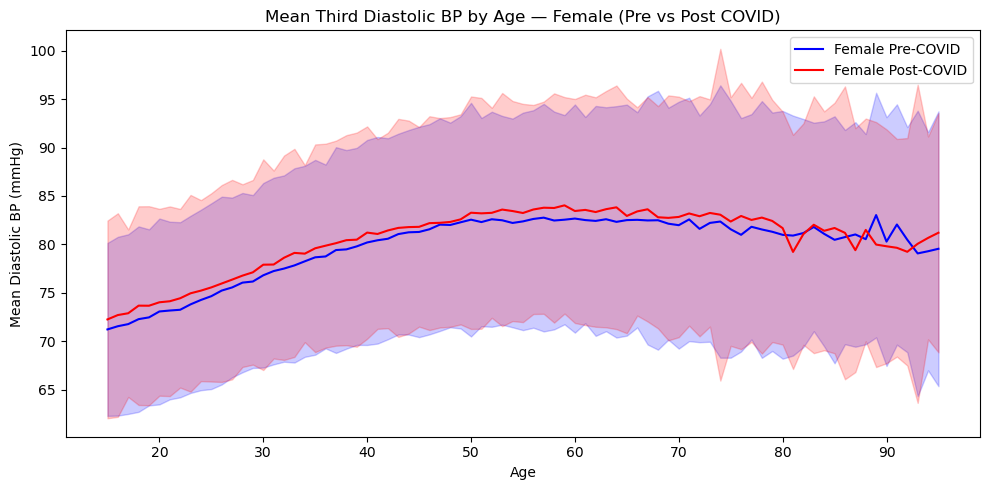

In [ ]:
def plot_bp_by_age_covid(pre, post, gender):
    for bp_col, bp_label in [(SBP_COL, 'Systolic'), (DBP_COL, 'Diastolic')]:
        fig, ax = plt.subplots(figsize=(10, 5))
        for df, color, lbl in [(pre, COLOR_PRE, 'Pre-COVID'), (post, COLOR_POST, 'Post-COVID')]:
            tmp = df[['Age of household members', bp_col, 'weight']].dropna()
            grouped = tmp.groupby('Age of household members').apply(
                lambda g: pd.Series({'wmean': np.average(g[bp_col], weights=g['weight'])}))
            ax.plot(grouped.index, grouped['wmean'], color=color, label=f'{gender} {lbl}', linewidth=1.5)
        ax.set_title(f'Weighted Mean {bp_label} BP by Age — {gender} (Pre vs Post COVID)')
        ax.set_xlabel('Age'); ax.set_ylabel(f'{bp_label} BP (mmHg)')
        plt.tight_layout()
        fig.savefig(f'figs/covid_bp_by_age_{bp_label.lower()}_{gender.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()

plot_bp_by_age_covid(nfhs5_pre_covid_male, nfhs5_post_covid_male, 'Male')
plot_bp_by_age_covid(nfhs5_pre_covid_female, nfhs5_post_covid_female, 'Female')

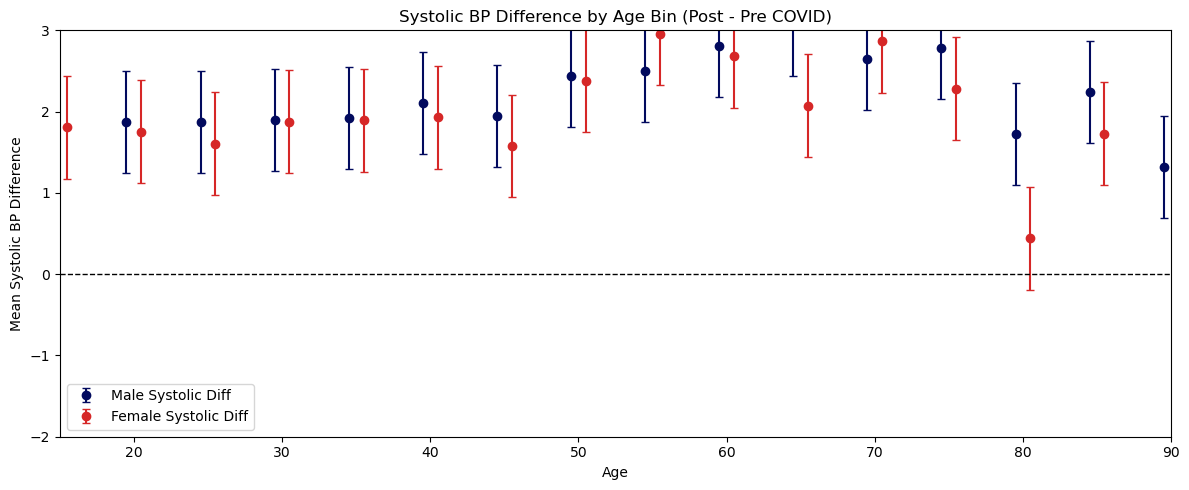

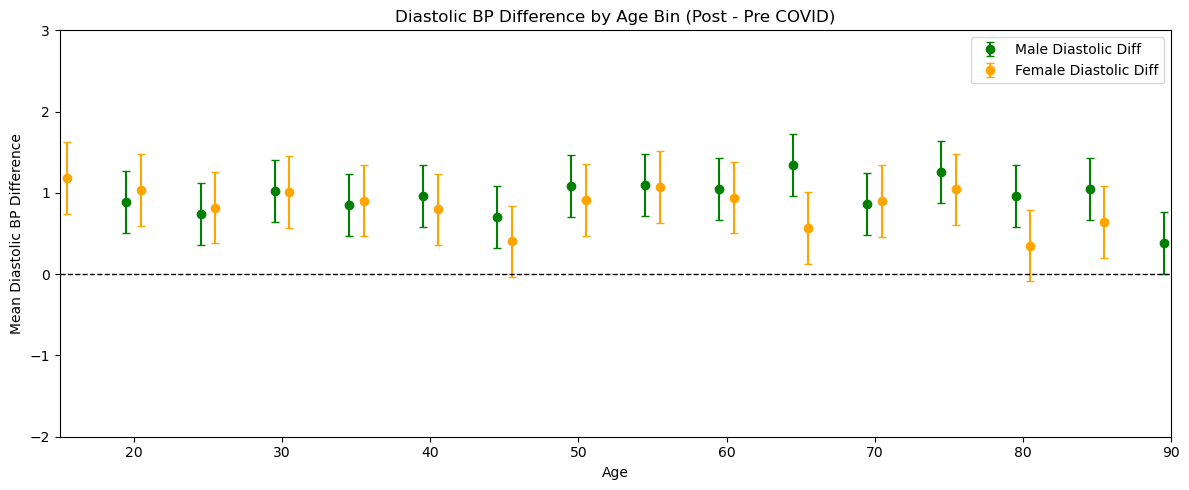

In [ ]:
def weighted_mean_se(vals, wts):
    mask = np.isfinite(vals) & np.isfinite(wts) & (wts > 0)
    v, w = vals[mask], wts[mask]
    if len(v) < 2:
        return np.nan, np.nan
    wm = np.average(v, weights=w)
    V1 = w.sum(); V2 = (w**2).sum()
    var = np.average((v - wm)**2, weights=w) * V1**2 / (V1**2 - V2)
    se = np.sqrt(var / len(v))
    return wm, se

def analyze_bp_shift_by_age(pre_m, post_m, pre_f, post_f, bin_width=5):
    dfs = {}
    for label, pre, post in [('male', pre_m, post_m), ('female', pre_f, post_f)]:
        p = pre.copy(); q = post.copy()
        p['Age_bin'] = np.floor(p['Age of household members'] / bin_width) * bin_width
        q['Age_bin'] = np.floor(q['Age of household members'] / bin_width) * bin_width
        bins = sorted(set(p['Age_bin']) & set(q['Age_bin']))
        results = {bp: {'diff': [], 'se': []} for bp in ['sys', 'dia']}
        for b in bins:
            for bp, col in [('sys', SBP_COL), ('dia', DBP_COL)]:
                pb = p[p['Age_bin'] == b]; qb = q[q['Age_bin'] == b]
                wm_post, se_post = weighted_mean_se(qb[col].values, qb['weight'].values)
                wm_pre, se_pre = weighted_mean_se(pb[col].values, pb['weight'].values)
                results[bp]['diff'].append(wm_post - wm_pre)
                results[bp]['se'].append(np.sqrt(se_post**2 + se_pre**2))
        dfs[label] = (bins, results)

    for bp_type, bp_key, colors in [
        ('Systolic', 'sys', [COLOR_MALE, COLOR_FEMALE]),
        ('Diastolic', 'dia', ['green', 'orange']),
    ]:
        fig, ax = plt.subplots(figsize=(12, 5))
        for i, (sex, clr, lbl) in enumerate(zip(['male', 'female'], colors, ['Male', 'Female'])):
            bins, res = dfs[sex]
            shift = -0.5 if i == 0 else 0.5
            ax.errorbar([b + shift for b in bins], res[bp_key]['diff'],
                       yerr=[1.96*s for s in res[bp_key]['se']],
                       fmt='o', color=clr, label=f'{lbl} {bp_type} Diff', capsize=3)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{bp_type} BP Difference by Age Bin (Post − Pre COVID, weighted)')
        ax.set_xlabel('Age'); ax.set_ylabel(f'Mean {bp_type} BP Difference (mmHg)')
        ax.set_xlim(15, 90); ax.set_ylim(-2, 3)
        ax.legend(); plt.tight_layout()
        fig.savefig(f'figs/covid_bp_shift_{bp_type.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()

analyze_bp_shift_by_age(nfhs5_pre_covid_male, nfhs5_post_covid_male,
                        nfhs5_pre_covid_female, nfhs5_post_covid_female)


# Figure 1 — NFHS-5 vs NFHS-4 Year-Pair Heatmaps



In [12]:
for df_sex in [male_2016, female_2016]:
    df_sex.dropna(subset=['Year of interview'], inplace=True)

female_2015  = female_2016[female_2016['Year of interview'] == 2015]
female_2016y = female_2016[female_2016['Year of interview'] == 2016]
male_2015    = male_2016[male_2016['Year of interview'] == 2015]
male_2016y   = male_2016[male_2016['Year of interview'] == 2016]

print(f"NFHS-4 2015 — Male: {len(male_2015):,}   Female: {len(female_2015):,}")
print(f"NFHS-4 2016 — Male: {len(male_2016y):,}   Female: {len(female_2016y):,}")

NFHS-4 2015 — Male: 53,903   Female: 355,304
NFHS-4 2016 — Male: 57,707   Female: 344,696


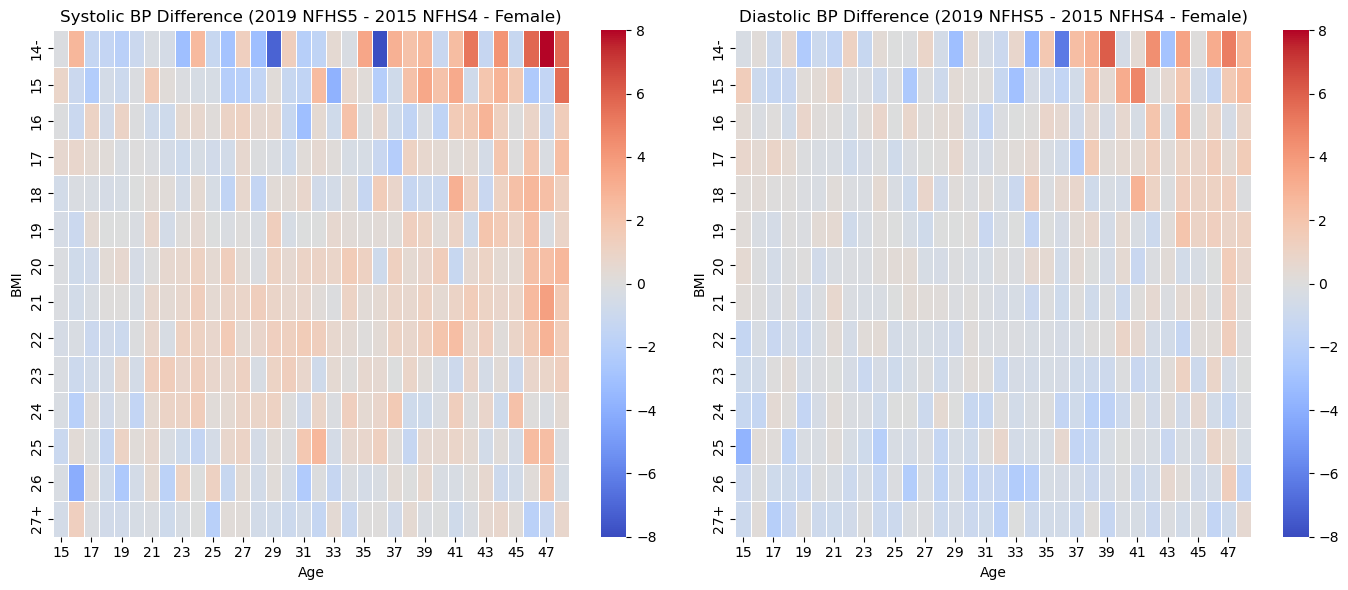

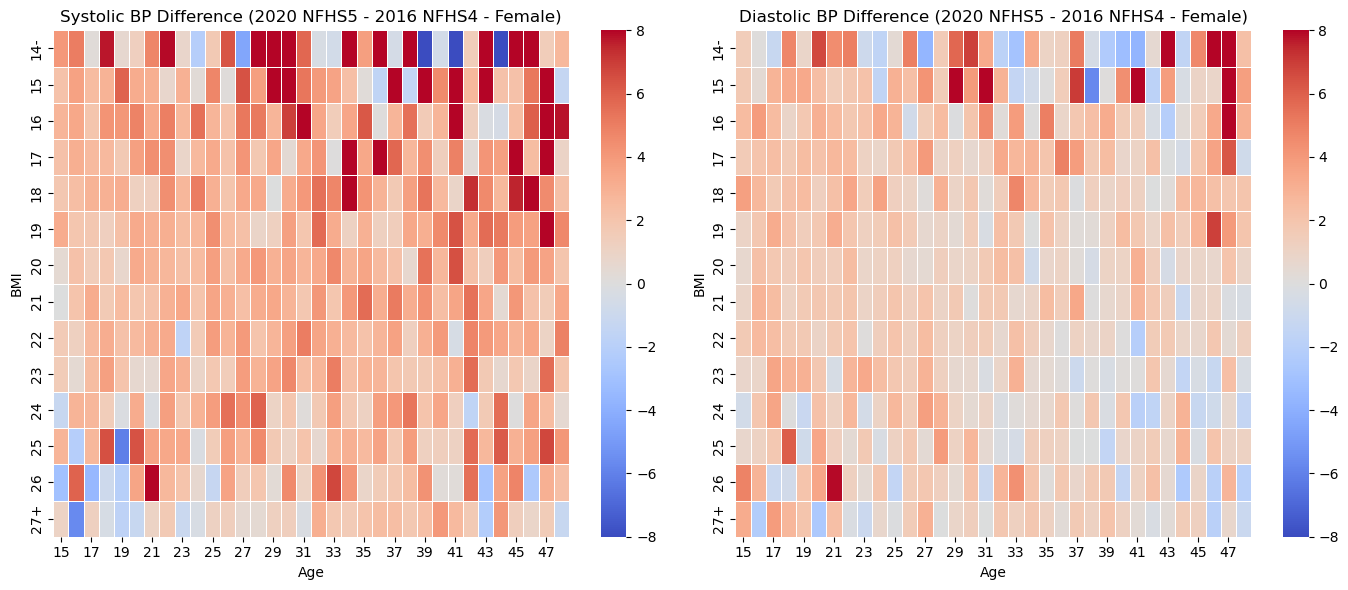

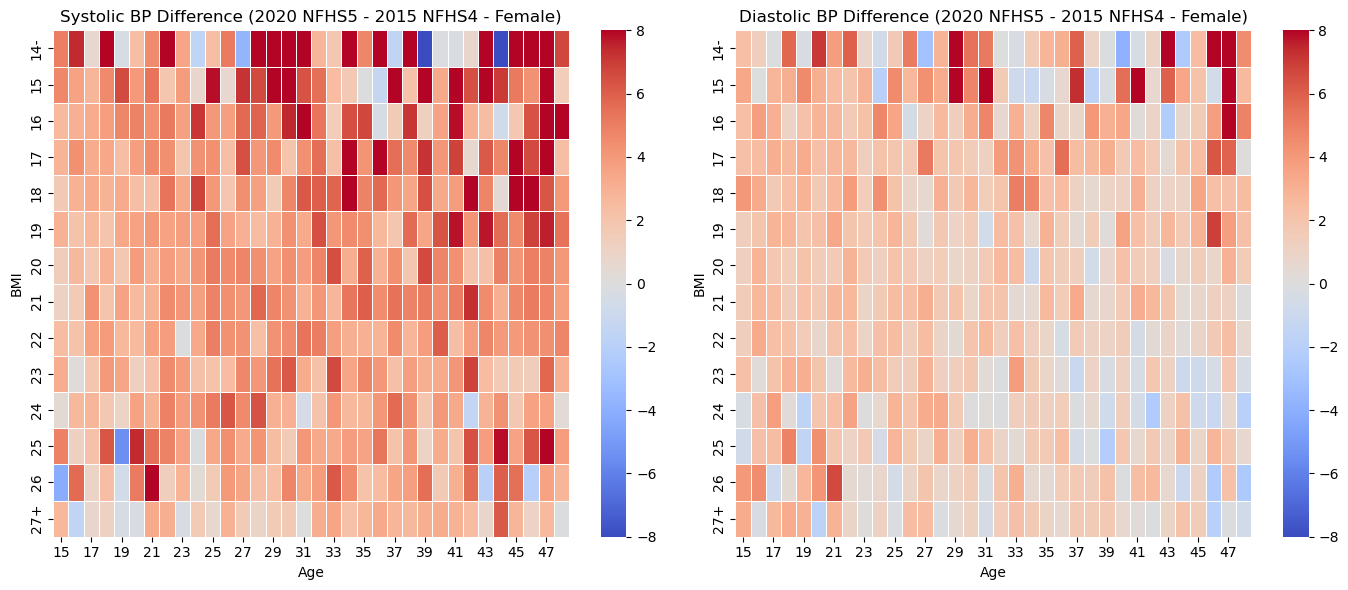

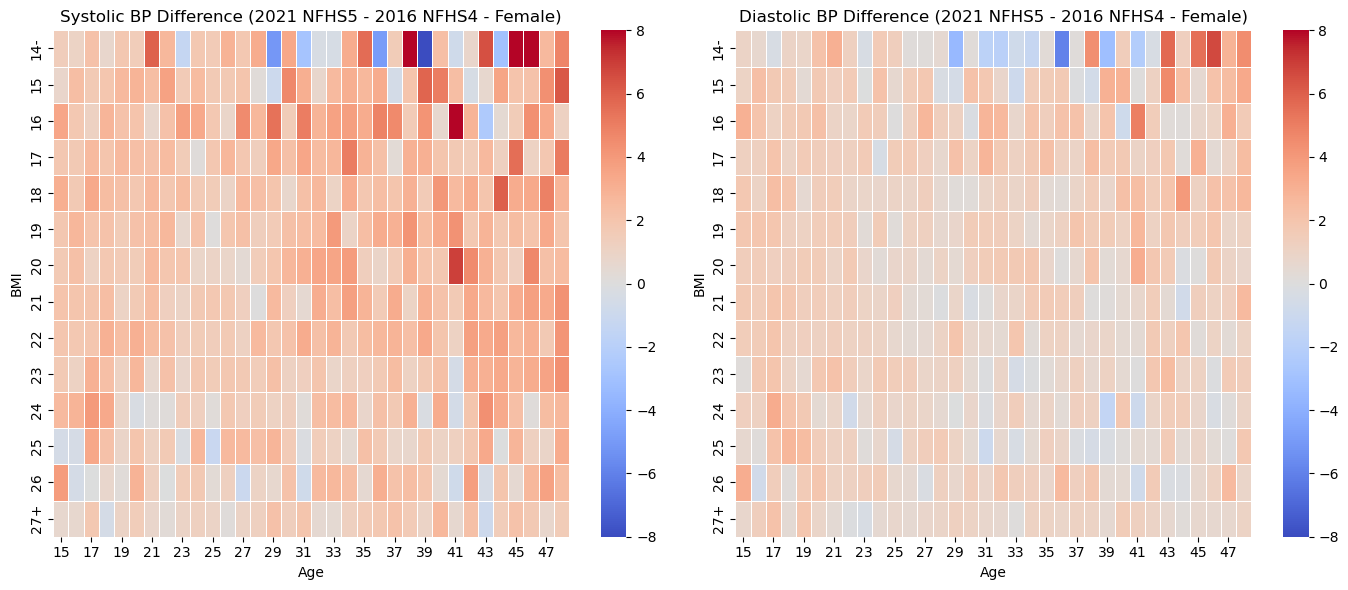

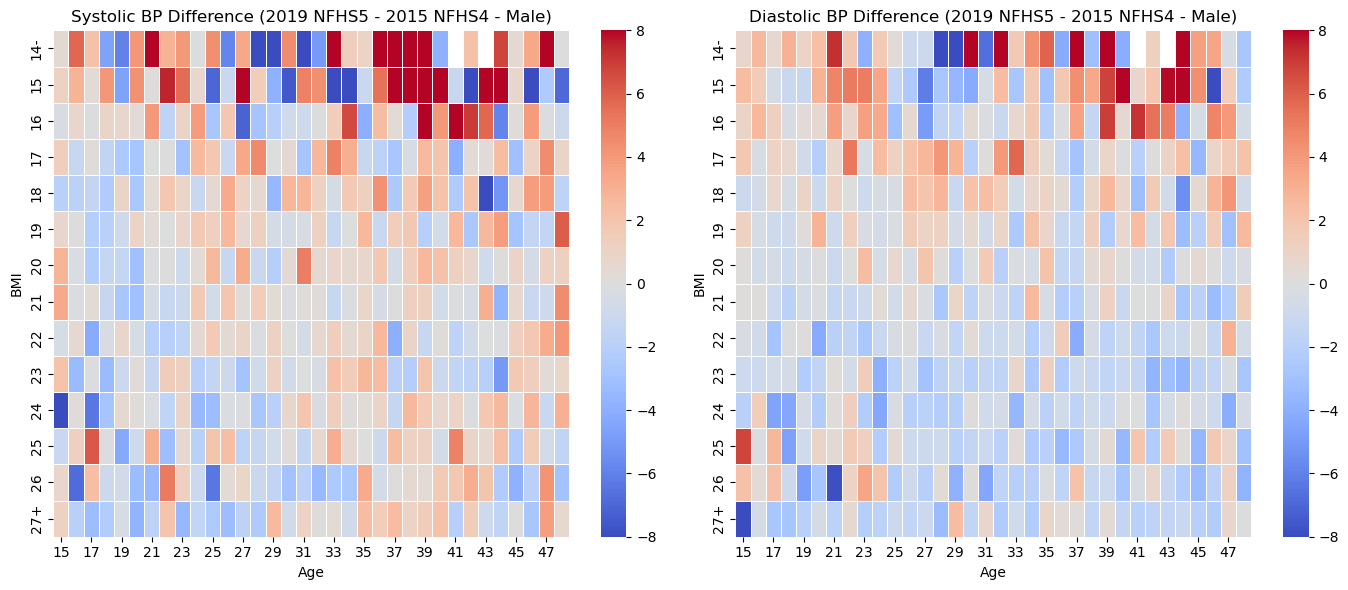

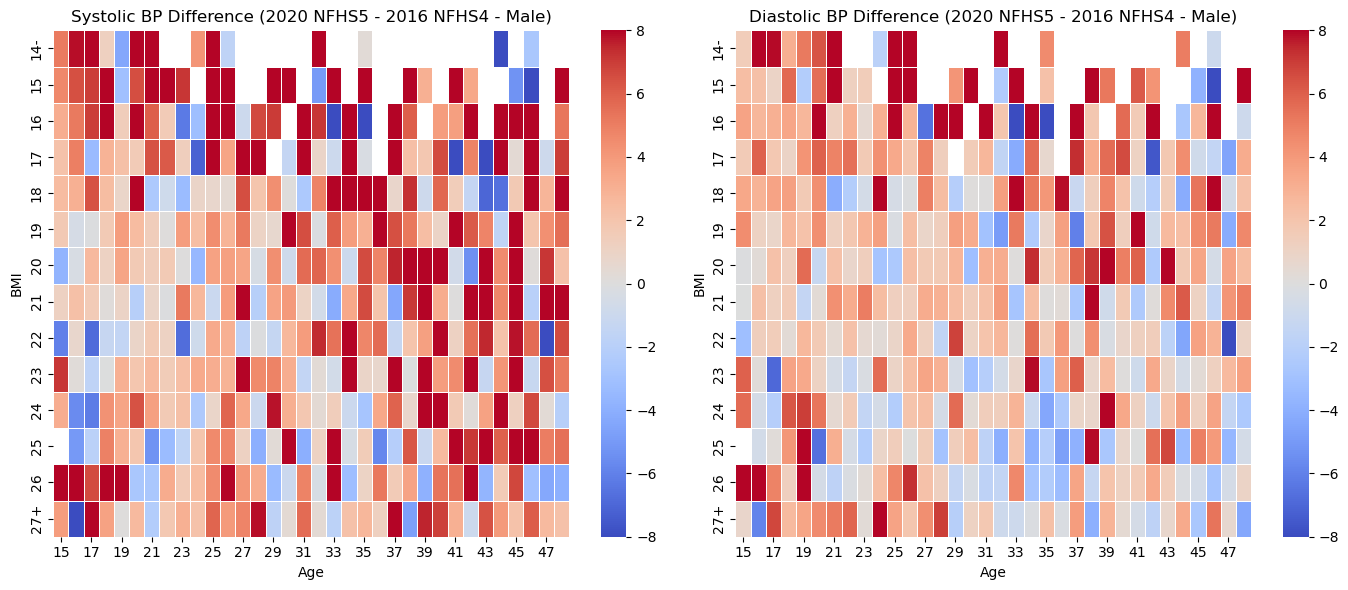

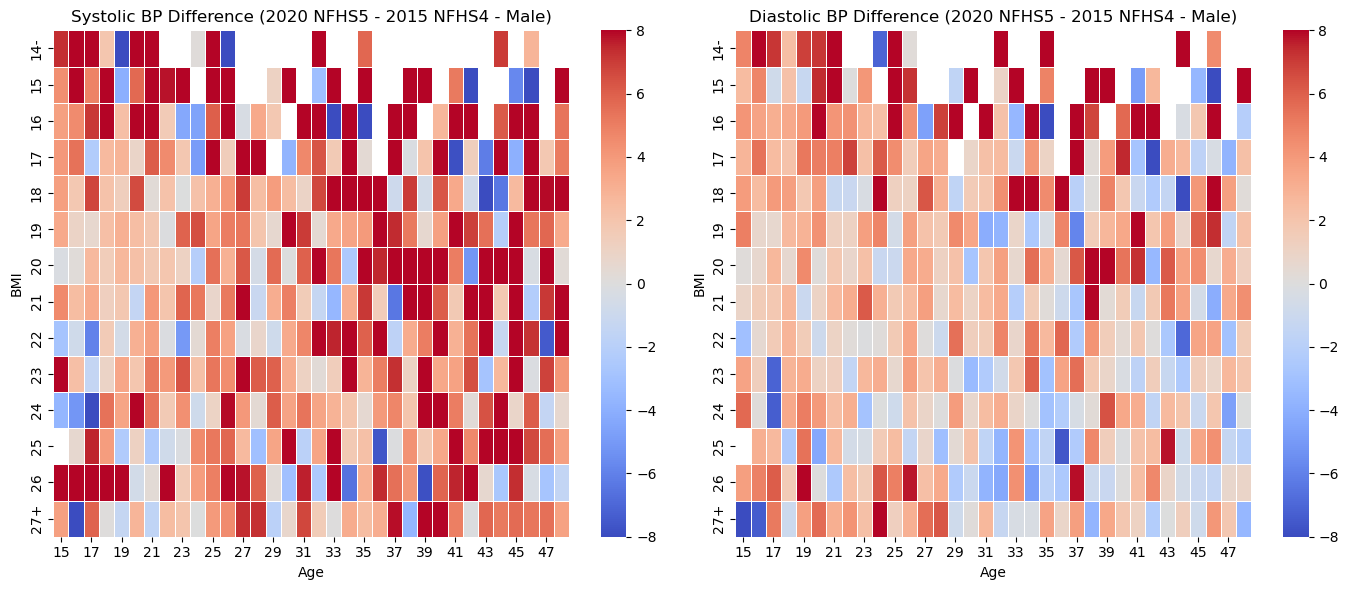

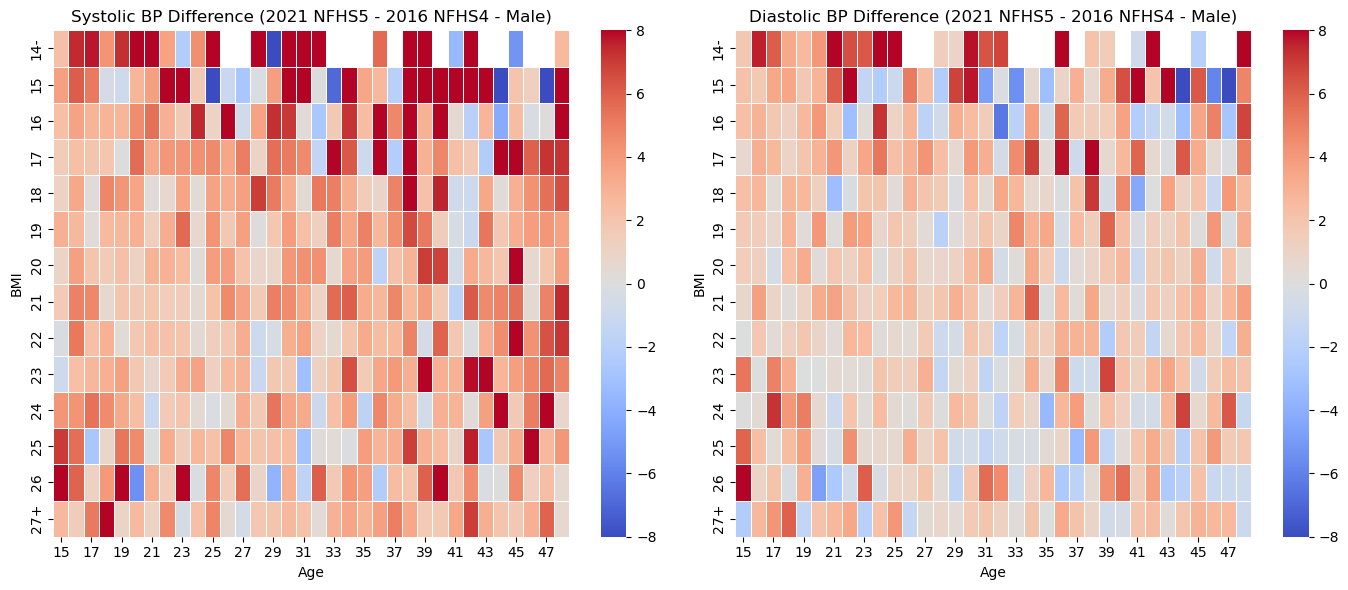

In [13]:
for label, base, comp in [
    ('(2019 NFHS5 - 2015 NFHS4 - Female)', female_2015, female_2019),
    ('(2020 NFHS5 - 2016 NFHS4 - Female)', female_2016y, female_2020),
    ('(2020 NFHS5 - 2015 NFHS4 - Female)', female_2015, female_2020),
    ('(2021 NFHS5 - 2016 NFHS4 - Female)', female_2016y, female_2021o),
    ('(2019 NFHS5 - 2015 NFHS4 - Male)', male_2015, male_2019),
    ('(2020 NFHS5 - 2016 NFHS4 - Male)', male_2016y, male_2020),
    ('(2020 NFHS5 - 2015 NFHS4 - Male)', male_2015, male_2020),
    ('(2021 NFHS5 - 2016 NFHS4 - Male)', male_2016y, male_2021o),
]:
    res = get_mean_bp_by_age_bmi(base, comp, bmi_dict=bmi_ranges)
    plot_heatmap(prepare_heatmap_data(res), label)


# Pre/Post COVID NFHS-5 vs NFHS-4



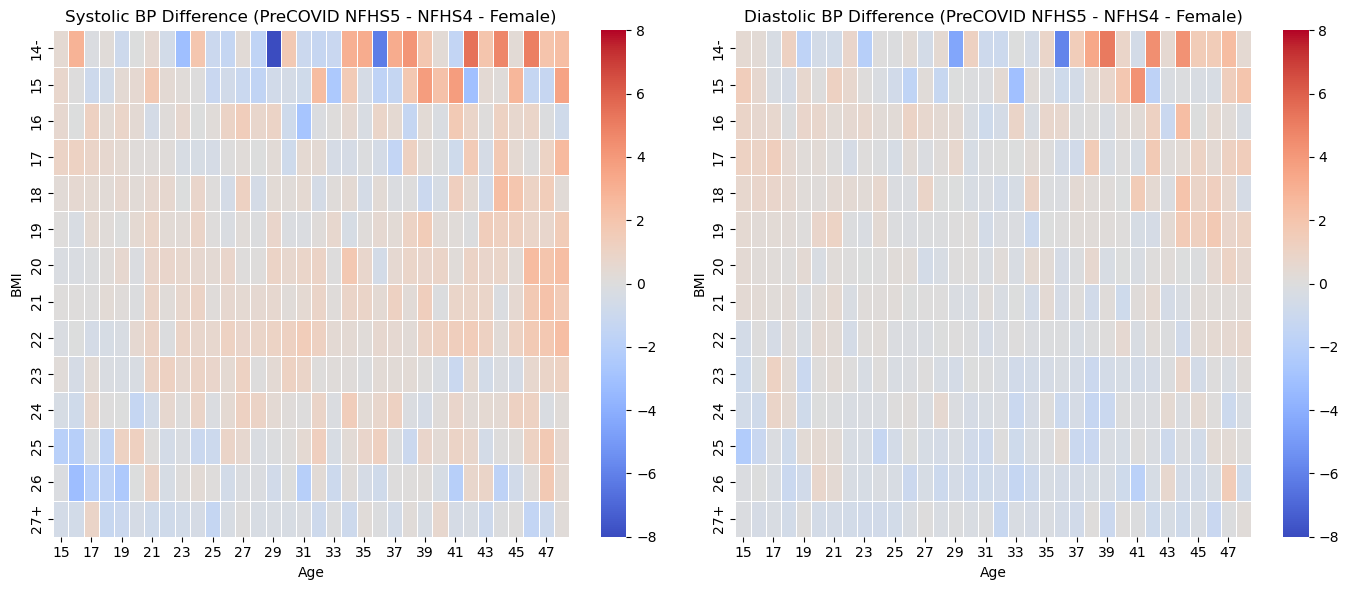

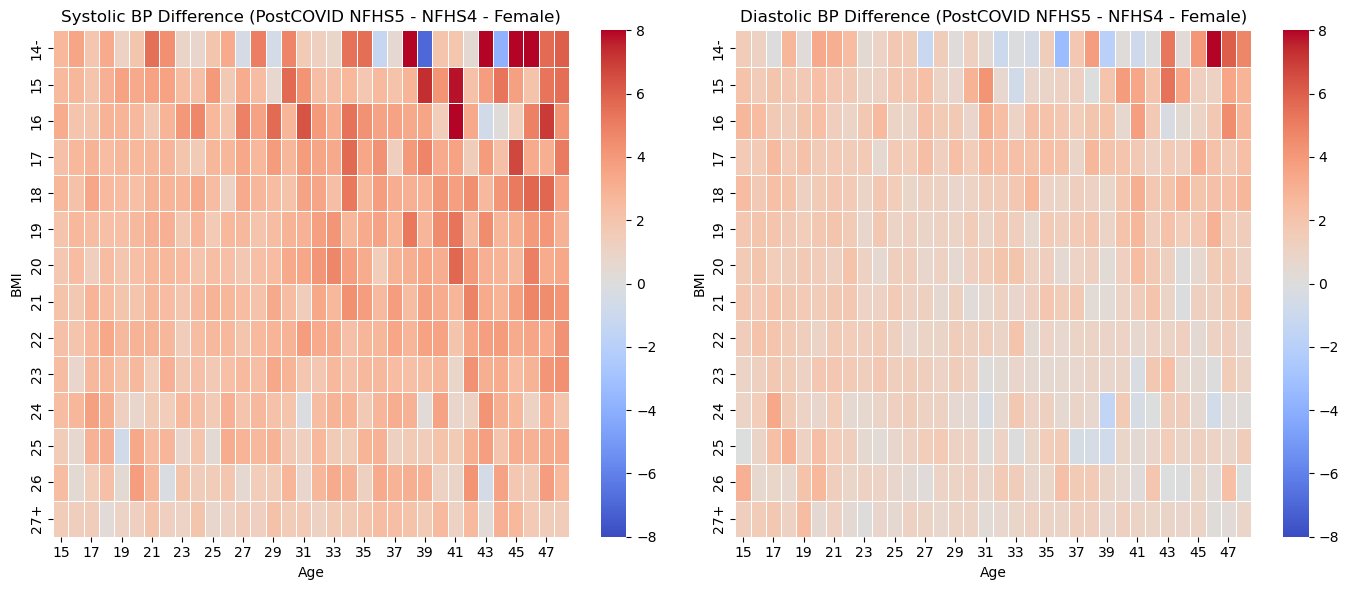

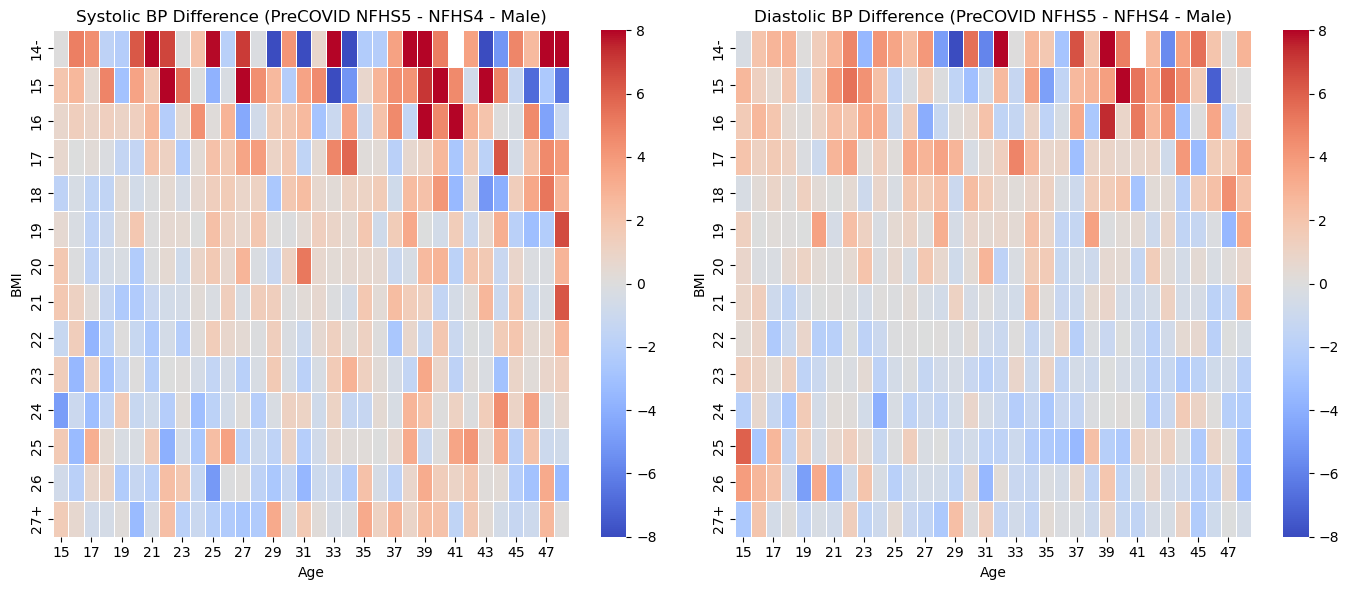

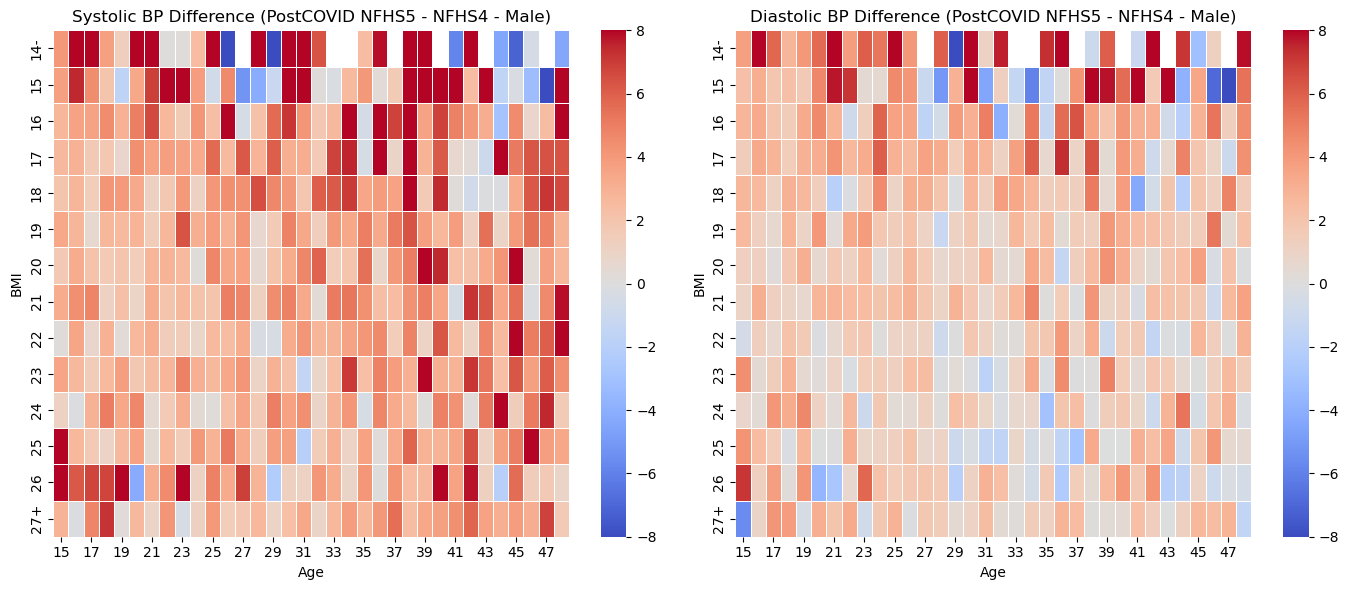

In [14]:
for label, base, comp in [
    ('(PreCOVID NFHS5 - NFHS4 - Female)', female_2016, nfhs5_pre_covid_female),
    ('(PostCOVID NFHS5 - NFHS4 - Female)', female_2016, nfhs5_post_covid_female),
    ('(PreCOVID NFHS5 - NFHS4 - Male)', male_2016, nfhs5_pre_covid_male),
    ('(PostCOVID NFHS5 - NFHS4 - Male)', male_2016, nfhs5_post_covid_male),
]:
    res = get_mean_bp_by_age_bmi(base, comp, bmi_dict=bmi_ranges)
    plot_heatmap(prepare_heatmap_data(res), label)


# State-Matched NFHS-4 Analysis



In [15]:
PHASE2_STATE_CODES = {4, 5, 6, 7, 13, 15, 17, 18, 19, 30, 31, 34, 35}

nfhs4_pre_eq_male    = male_2016[~male_2016['State code'].isin(PHASE2_STATE_CODES)]
nfhs4_post_eq_male   = male_2016[male_2016['State code'].isin(PHASE2_STATE_CODES)]
nfhs4_pre_eq_female  = female_2016[~female_2016['State code'].isin(PHASE2_STATE_CODES)]
nfhs4_post_eq_female = female_2016[female_2016['State code'].isin(PHASE2_STATE_CODES)]

print(f"NFHS-4 Pre-eq  (Phase 1 states) — Male: {len(nfhs4_pre_eq_male):,}   Female: {len(nfhs4_pre_eq_female):,}")
print(f"NFHS-4 Post-eq (Phase 2 states) — Male: {len(nfhs4_post_eq_male):,}   Female: {len(nfhs4_post_eq_female):,}")

NFHS-4 Pre-eq  (Phase 1 states) — Male: 67,462   Female: 415,674
NFHS-4 Post-eq (Phase 2 states) — Male: 44,148   Female: 284,326


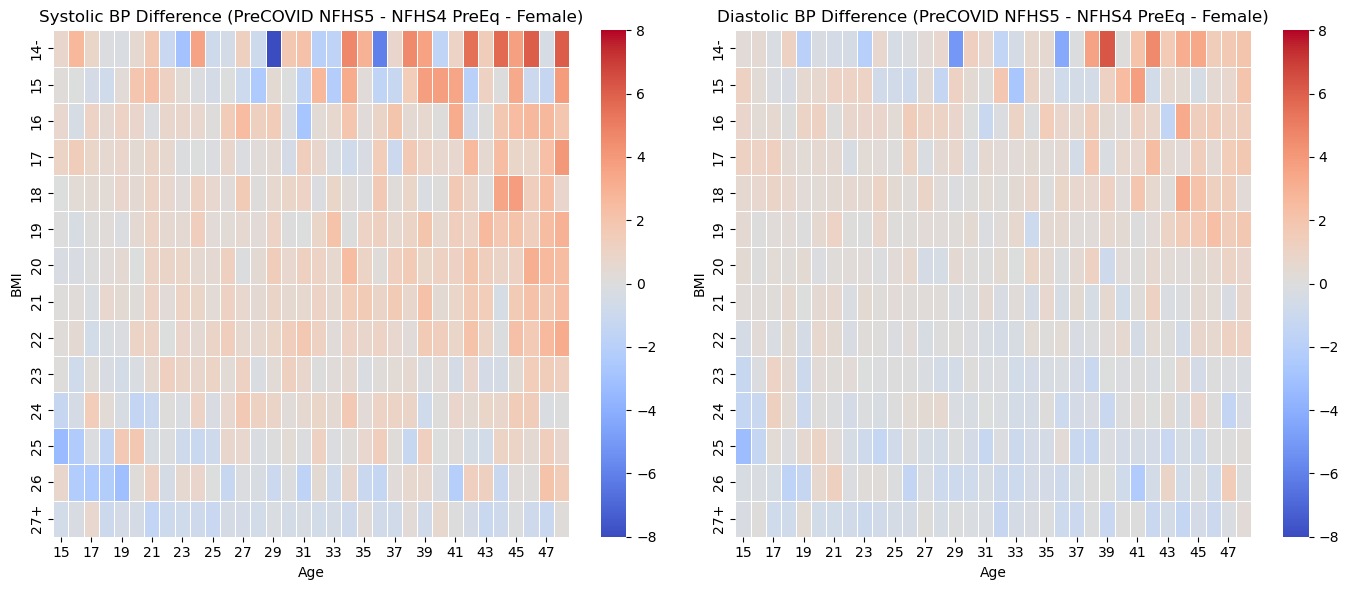

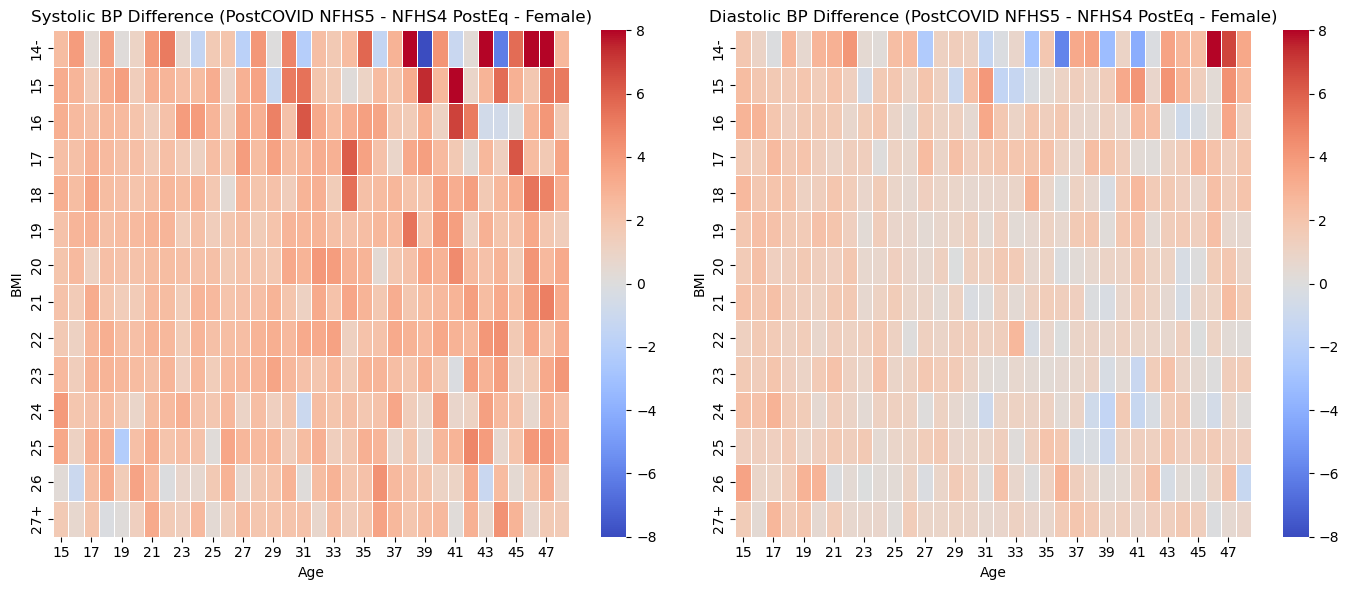

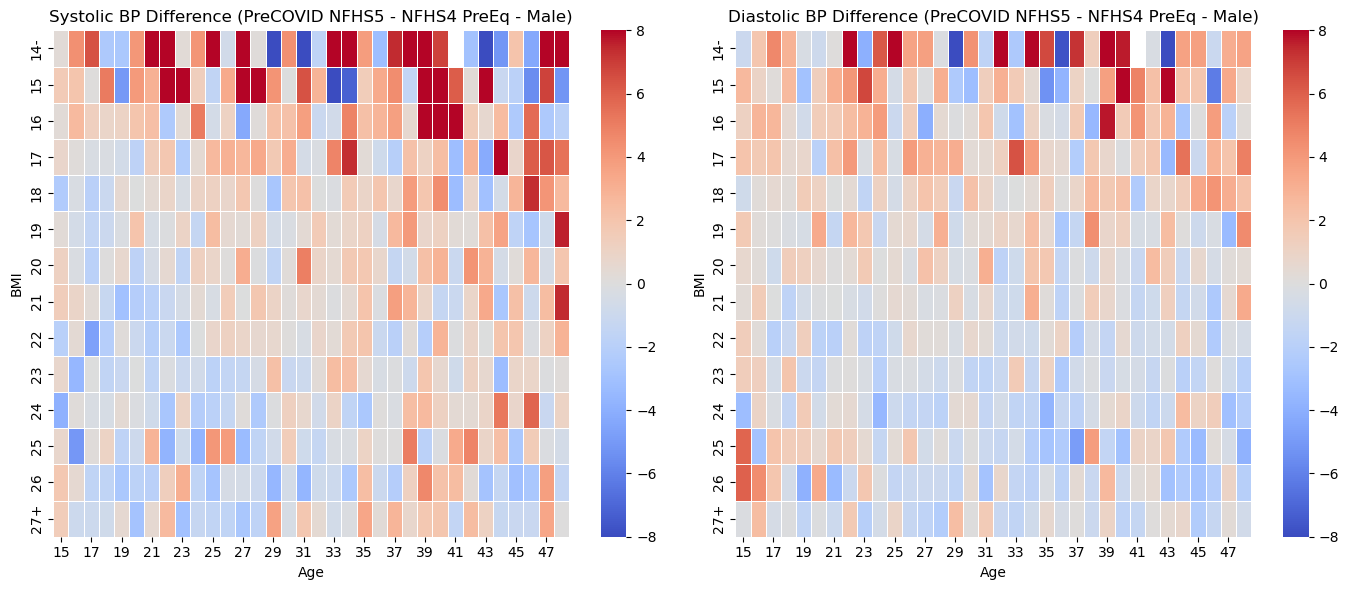

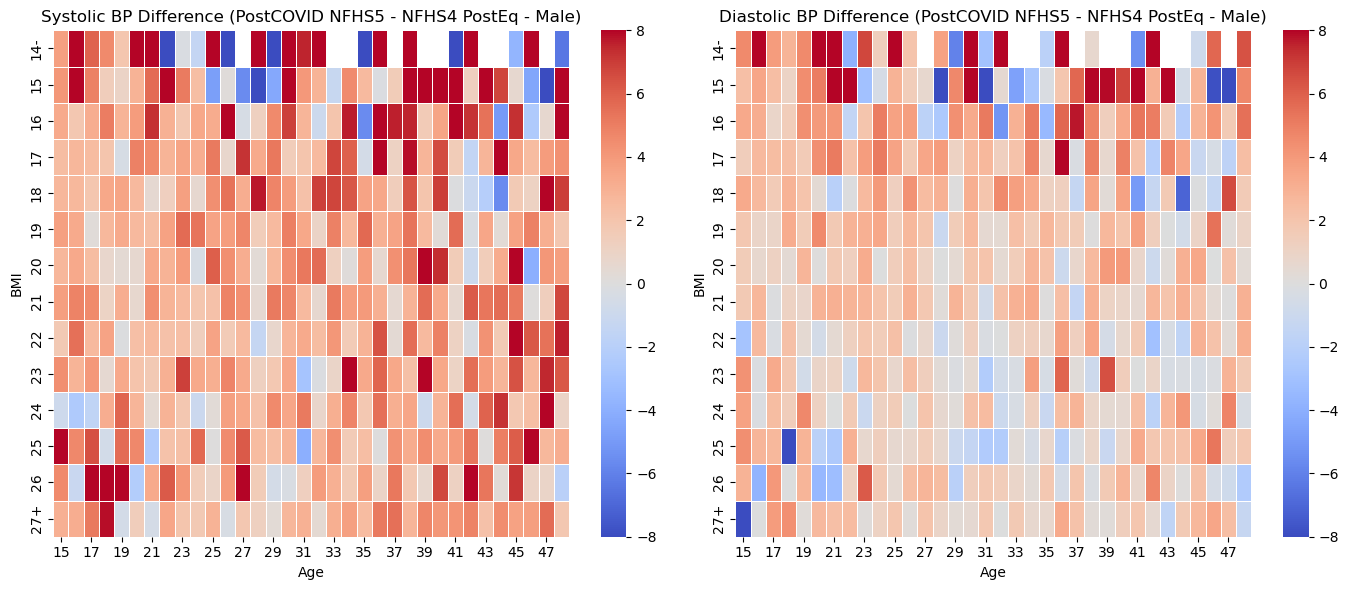

In [16]:

for label, base, comp in [
    ('(PreCOVID NFHS5 - NFHS4 PreEq - Female)', nfhs4_pre_eq_female, nfhs5_pre_covid_female),
    ('(PostCOVID NFHS5 - NFHS4 PostEq - Female)', nfhs4_post_eq_female, nfhs5_post_covid_female),
    ('(PreCOVID NFHS5 - NFHS4 PreEq - Male)', nfhs4_pre_eq_male, nfhs5_pre_covid_male),
    ('(PostCOVID NFHS5 - NFHS4 PostEq - Male)', nfhs4_post_eq_male, nfhs5_post_covid_male),
]:
    res = get_mean_bp_by_age_bmi(base, comp, bmi_dict=bmi_ranges)
    plot_heatmap(prepare_heatmap_data(res), label)

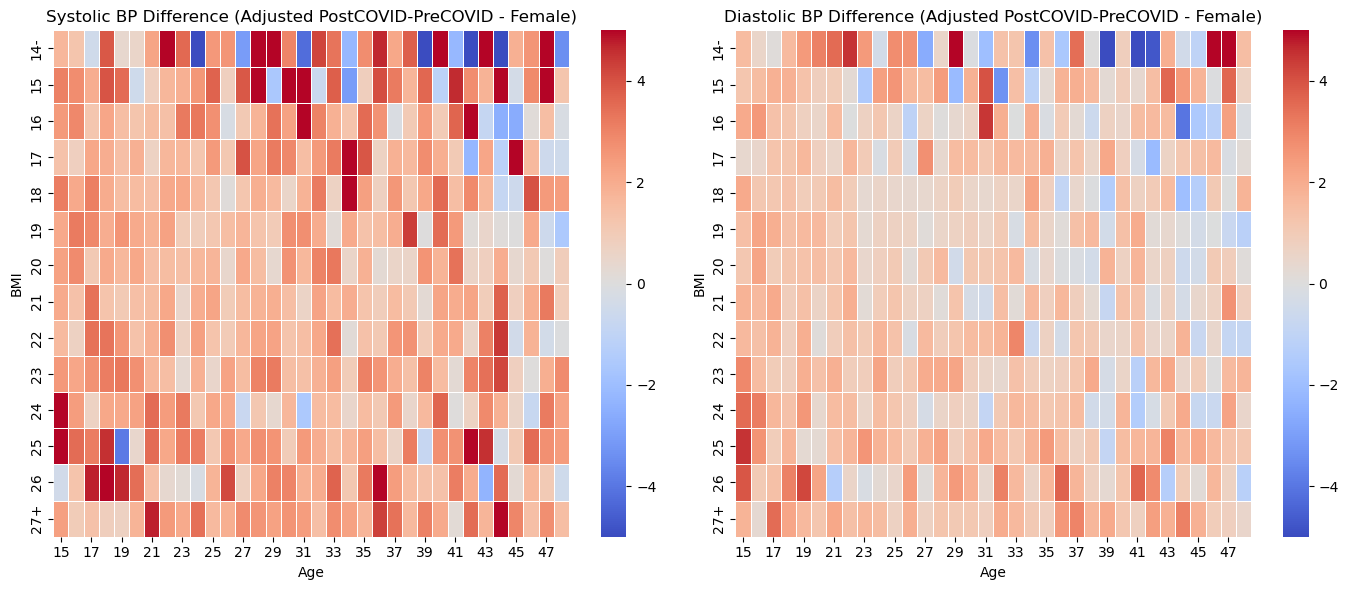

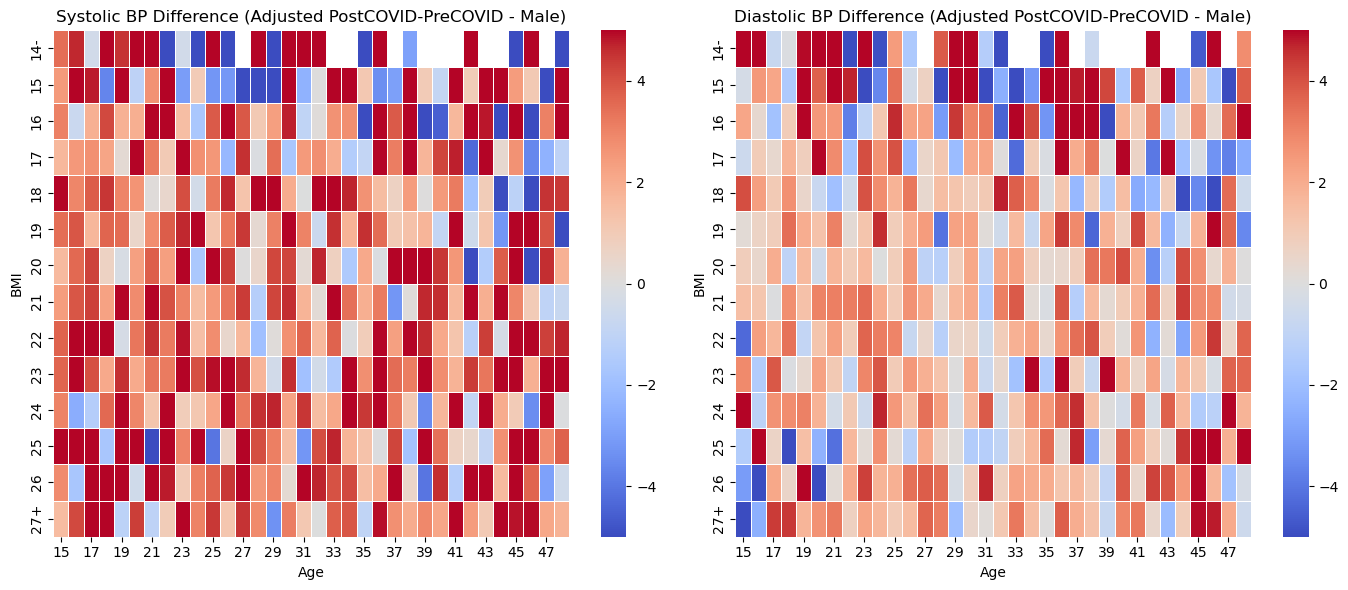

In [17]:
# Final adjusted comparison: (PostCOVID NFHS5 - NFHS4 PostEq) - (PreCOVID NFHS5 - NFHS4 PreEq)
for gender, pre_n5, post_n5, pre_n4, post_n4 in [
    ('Female', nfhs5_pre_covid_female, nfhs5_post_covid_female, nfhs4_pre_eq_female, nfhs4_post_eq_female),
    ('Male', nfhs5_pre_covid_male, nfhs5_post_covid_male, nfhs4_pre_eq_male, nfhs4_post_eq_male),
]:
    res_pre  = get_mean_bp_by_age_bmi(pre_n4, pre_n5, bmi_dict=bmi_ranges)
    res_post = get_mean_bp_by_age_bmi(post_n4, post_n5, bmi_dict=bmi_ranges)

    common_keys = set(res_pre.keys()) & set(res_post.keys())
    adjusted = {}
    for k in common_keys:
        adjusted[k] = {
            'systolic_diff': res_post[k]['systolic_diff'] - res_pre[k]['systolic_diff'],
            'diastolic_diff': res_post[k]['diastolic_diff'] - res_pre[k]['diastolic_diff'],
        }

    plot_heatmap(prepare_heatmap_data(adjusted), f'(Adjusted PostCOVID-PreCOVID - {gender})', vmin=-5, vmax=5)


# Year-Specific COVID vs NFHS-4

Post-COVID 2020/2021 and pre-COVID vs NFHS-4 2015/2016 by year

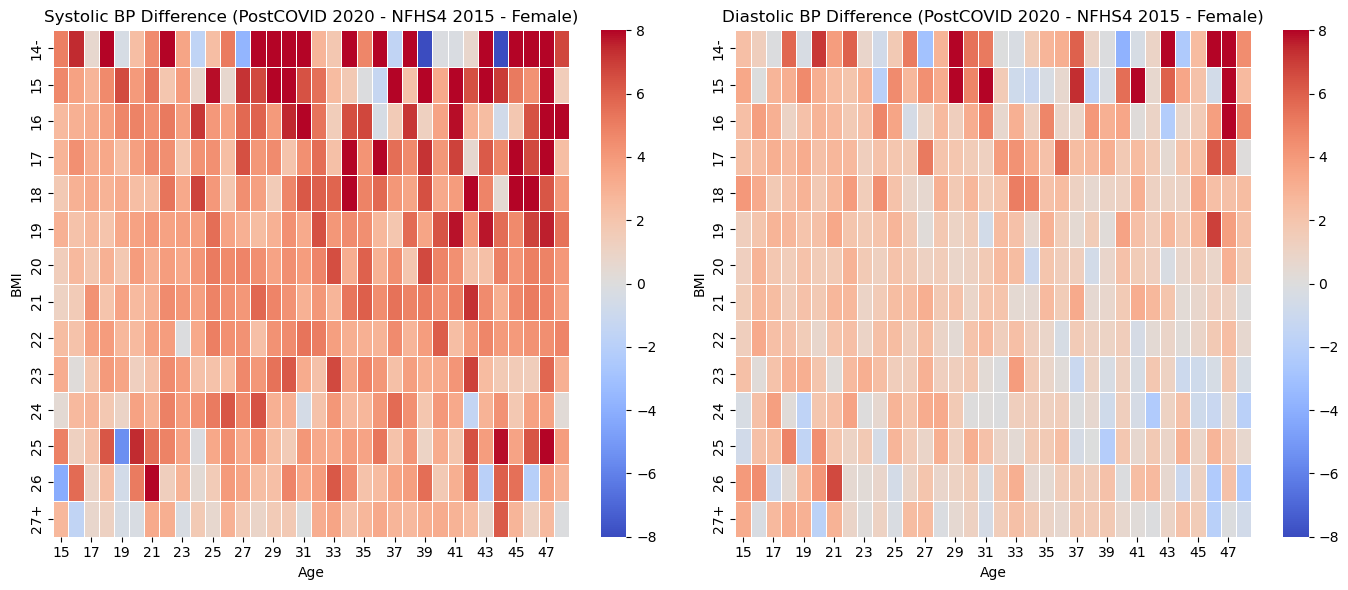

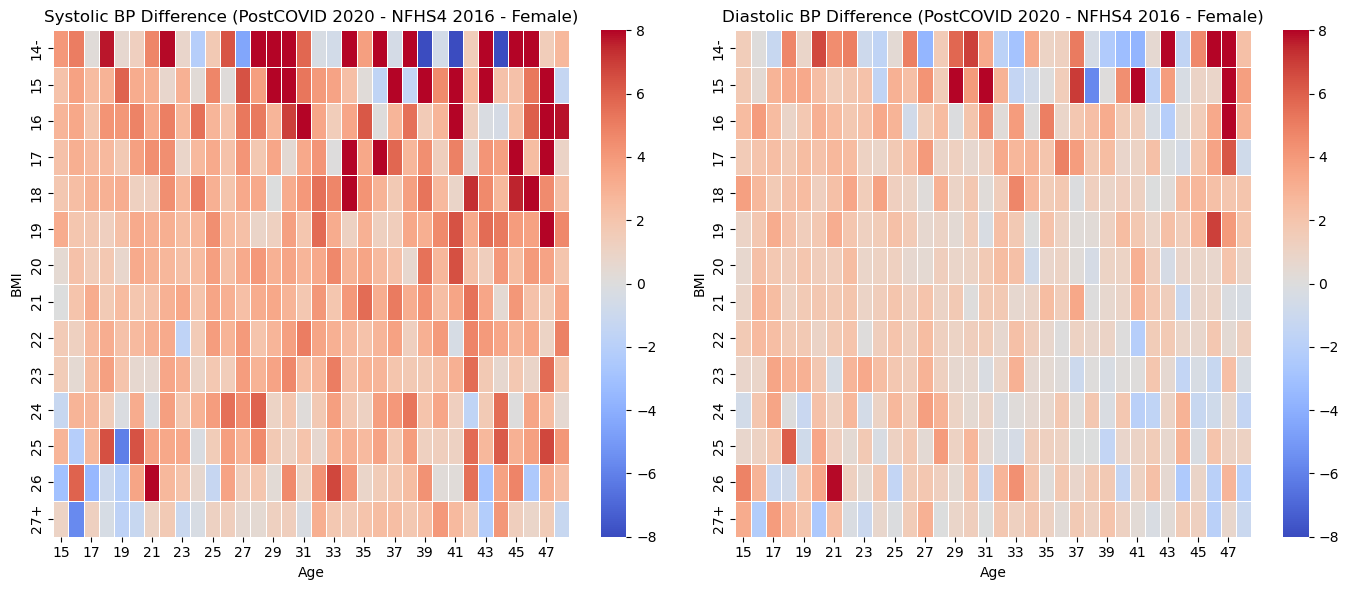

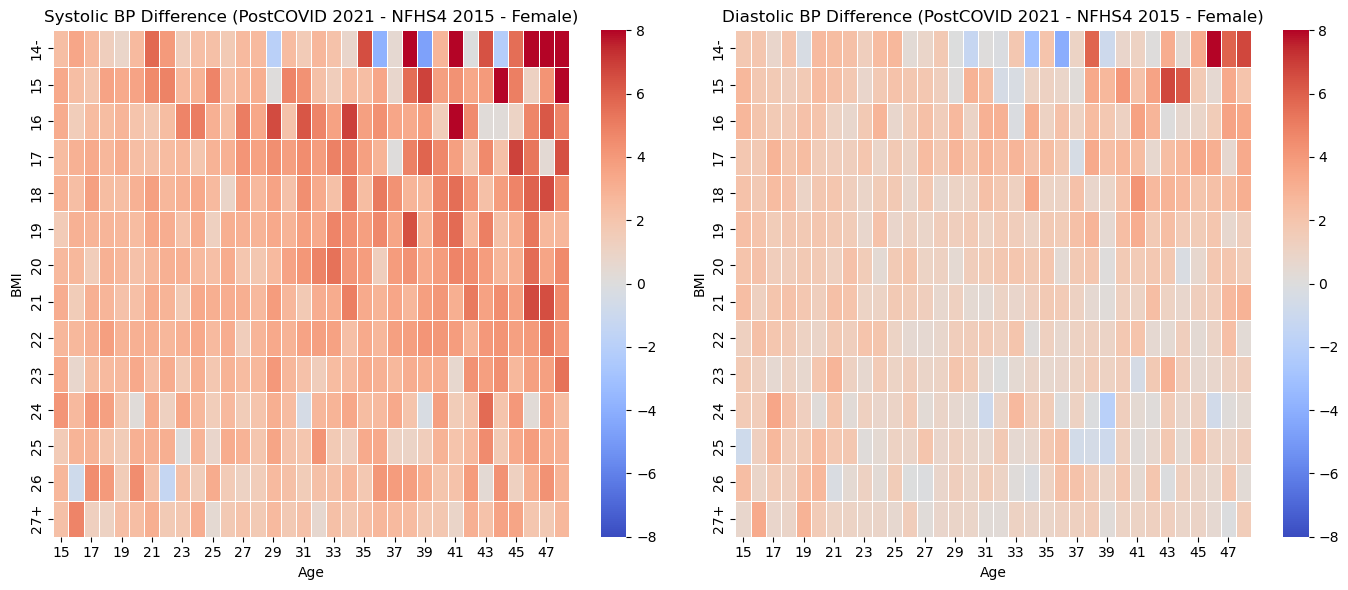

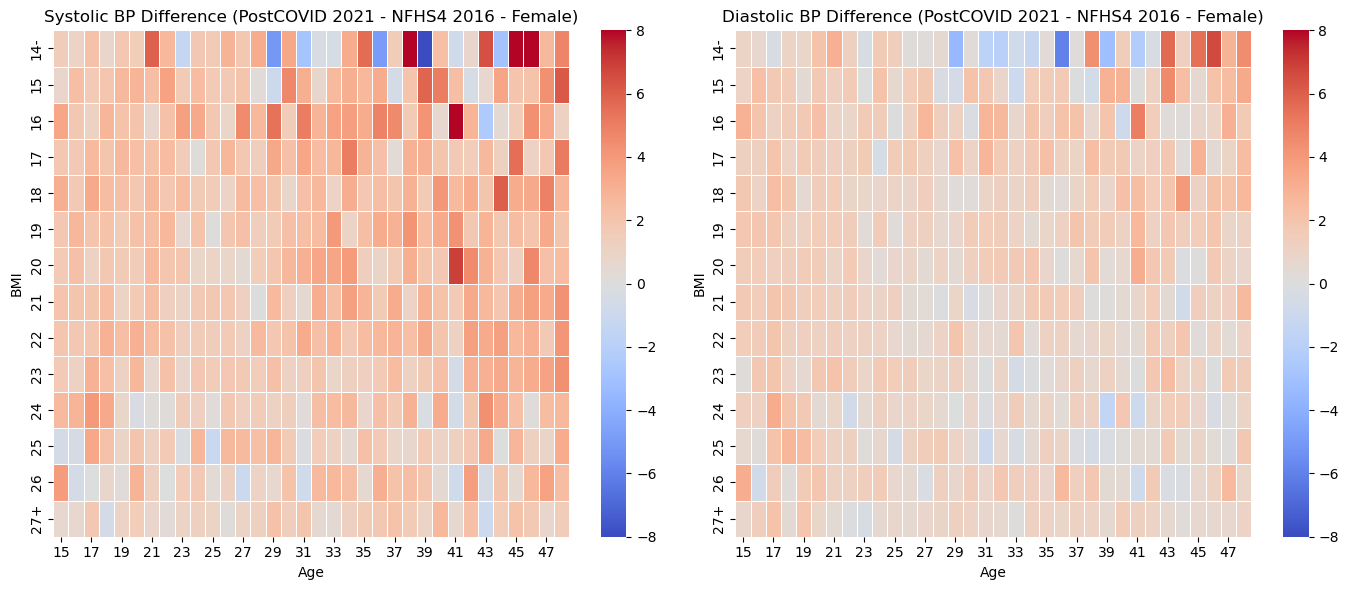

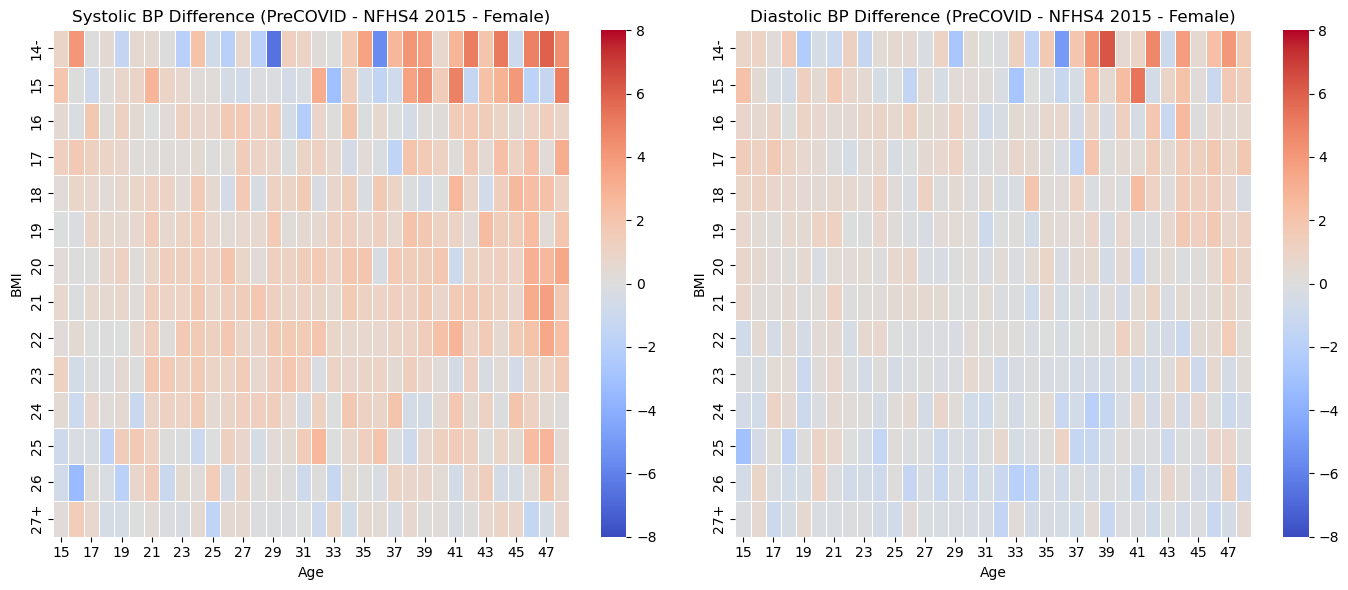

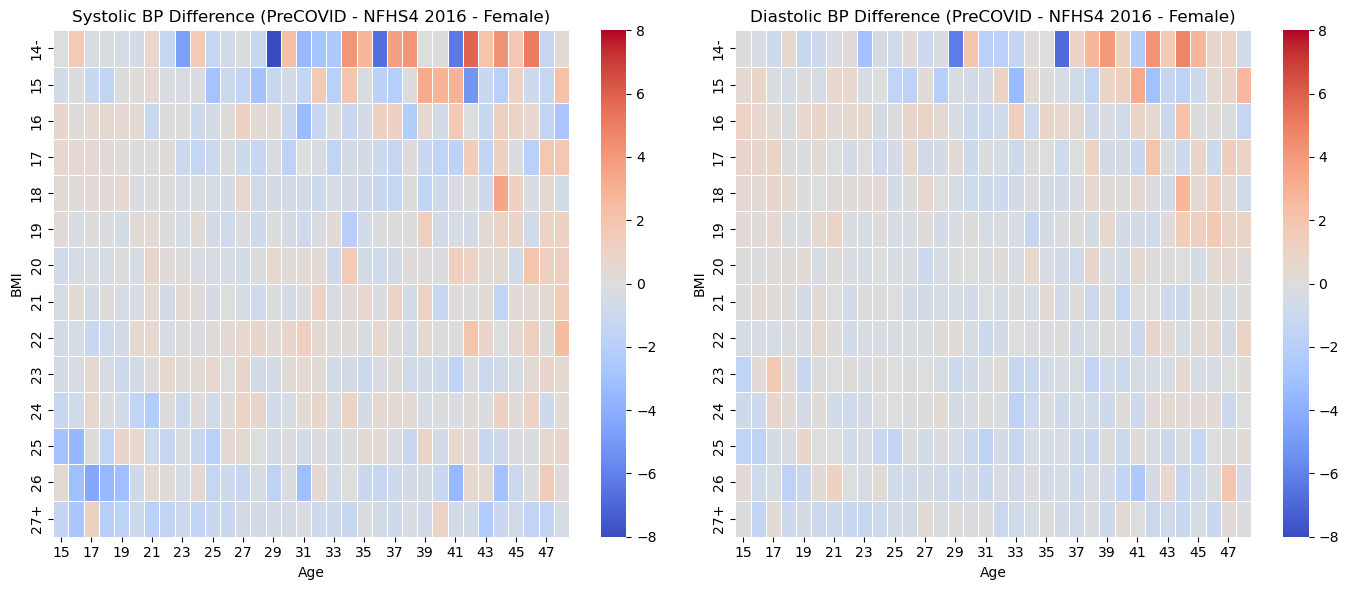

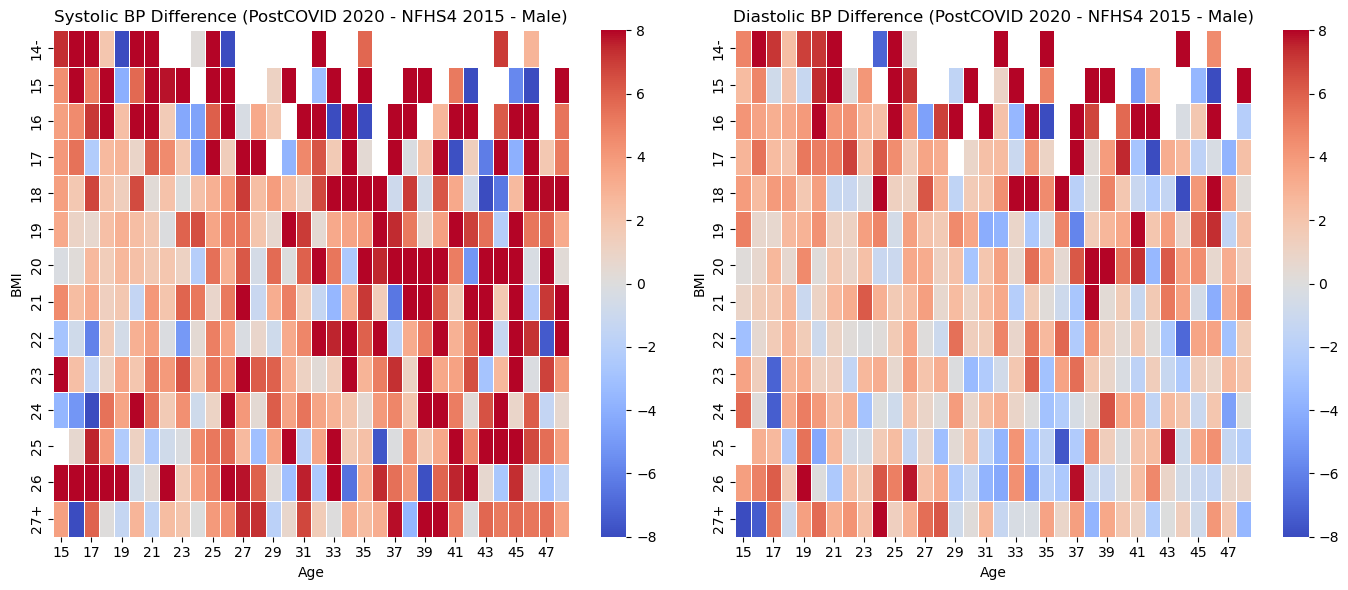

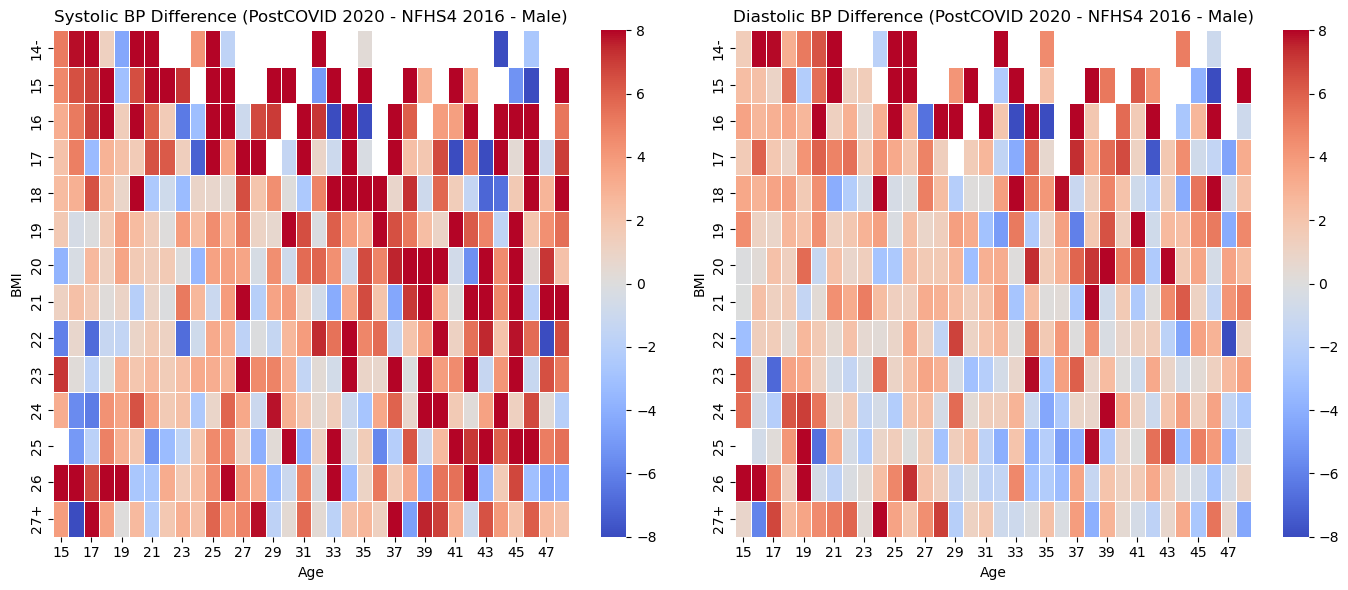

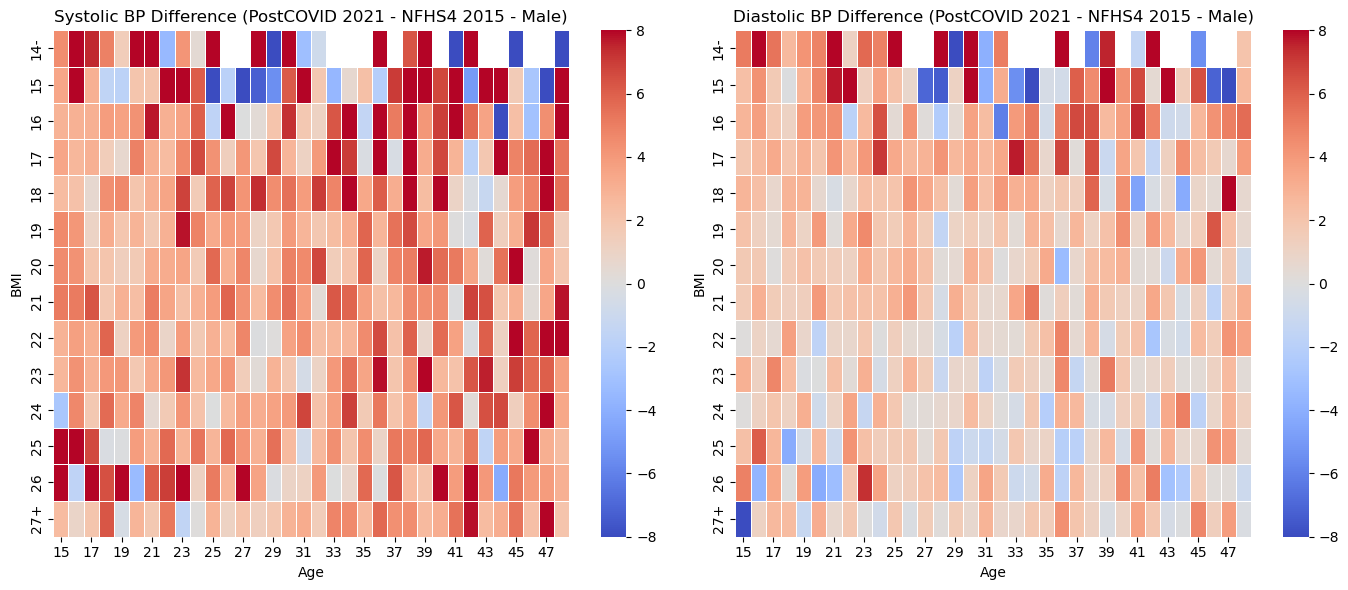

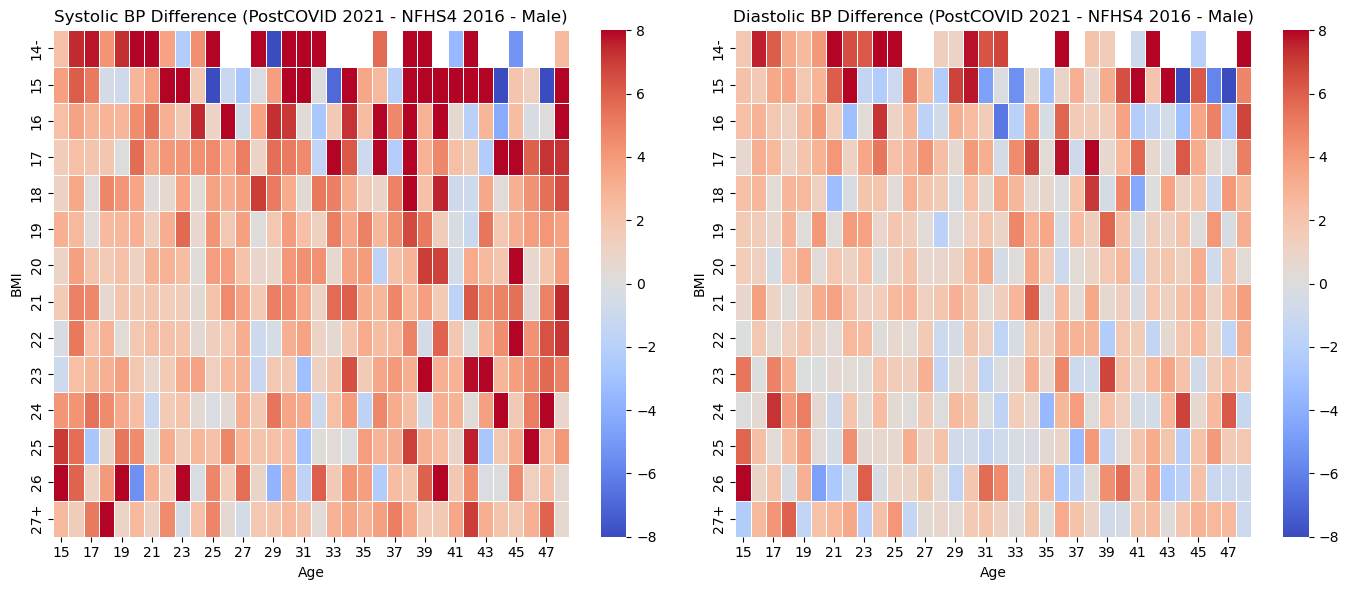

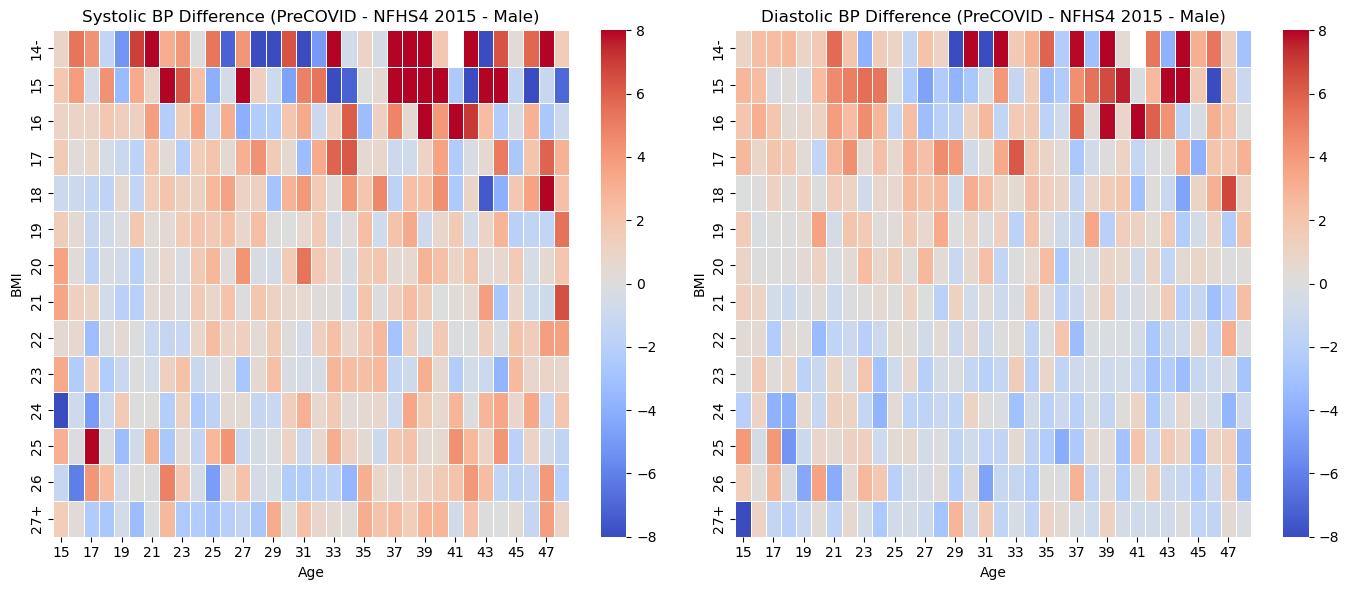

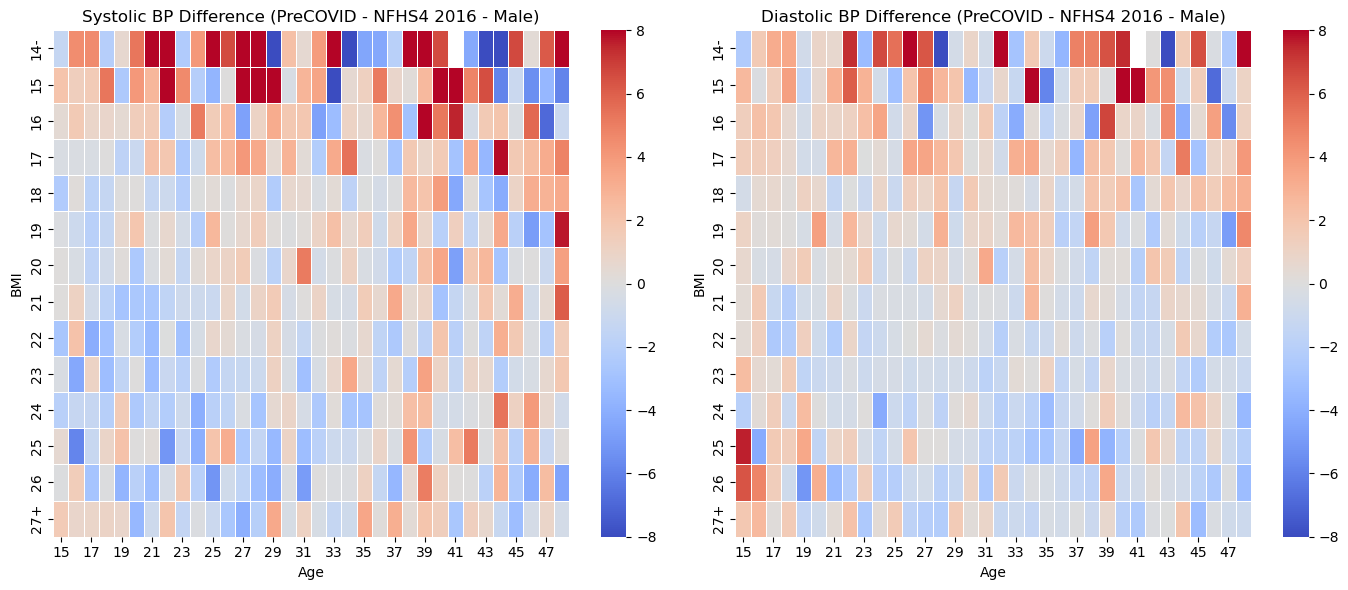

In [18]:
for label, base, comp in [
    ('(PostCOVID 2020 - NFHS4 2015 - Female)', female_2015, female_2020),
    ('(PostCOVID 2020 - NFHS4 2016 - Female)', female_2016y, female_2020),
    ('(PostCOVID 2021 - NFHS4 2015 - Female)', female_2015, female_2021o),
    ('(PostCOVID 2021 - NFHS4 2016 - Female)', female_2016y, female_2021o),
    ('(PreCOVID - NFHS4 2015 - Female)', female_2015, nfhs5_pre_covid_female),
    ('(PreCOVID - NFHS4 2016 - Female)', female_2016y, nfhs5_pre_covid_female),
    ('(PostCOVID 2020 - NFHS4 2015 - Male)', male_2015, male_2020),
    ('(PostCOVID 2020 - NFHS4 2016 - Male)', male_2016y, male_2020),
    ('(PostCOVID 2021 - NFHS4 2015 - Male)', male_2015, male_2021o),
    ('(PostCOVID 2021 - NFHS4 2016 - Male)', male_2016y, male_2021o),
    ('(PreCOVID - NFHS4 2015 - Male)', male_2015, nfhs5_pre_covid_male),
    ('(PreCOVID - NFHS4 2016 - Male)', male_2016y, nfhs5_pre_covid_male),
]:
    res = get_mean_bp_by_age_bmi(base, comp, bmi_dict=bmi_ranges)
    plot_heatmap(prepare_heatmap_data(res), label)